In [ ]:
# ── Setup: put src/ on the path, then build the analysis dataframe through the
#    configurable merger. All data paths live in src/config.py.
import os, sys
_p = os.getcwd()
while _p != os.path.dirname(_p):
    if os.path.isdir(os.path.join(_p, "src")):
        sys.path.insert(0, os.path.join(_p, "src")); break
    _p = os.path.dirname(_p)

from data_load import load_data_for_modeling, load_and_clean_accident_data
from topic_vd_analysis import run_topic_vd_analysis
import ruptures as rpt
import os
from typing import Dict, Optional, Tuple, Any
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns
from pathlib import Path

from analysis_data import build_analysis_dataframe

df_acc = build_analysis_dataframe(config="main_0.3")

## Analysis of Topic 11 — Active Hit-and-Run (*Stikflugt*)

Topic 11 captures **active hit-and-run** accidents: narratives dominated by *flugt* (flee), *flygtet* (fled), *ukendt part* (unknown party). Unlike topic 20 (note left on parked car), topic 11 involves a driver who strikes a person or vehicle while moving and immediately flees the scene. The topic holds **5,572 accidents** spanning the full 40-year corpus.

Seven analyses below establish: (1) rising temporal trend, (2) structural difference from topic 5, (3) geographic concentration, (4) severity excess, (5) situation-code invisibility, (6) victim profile, and (7) accident-type breakdown.

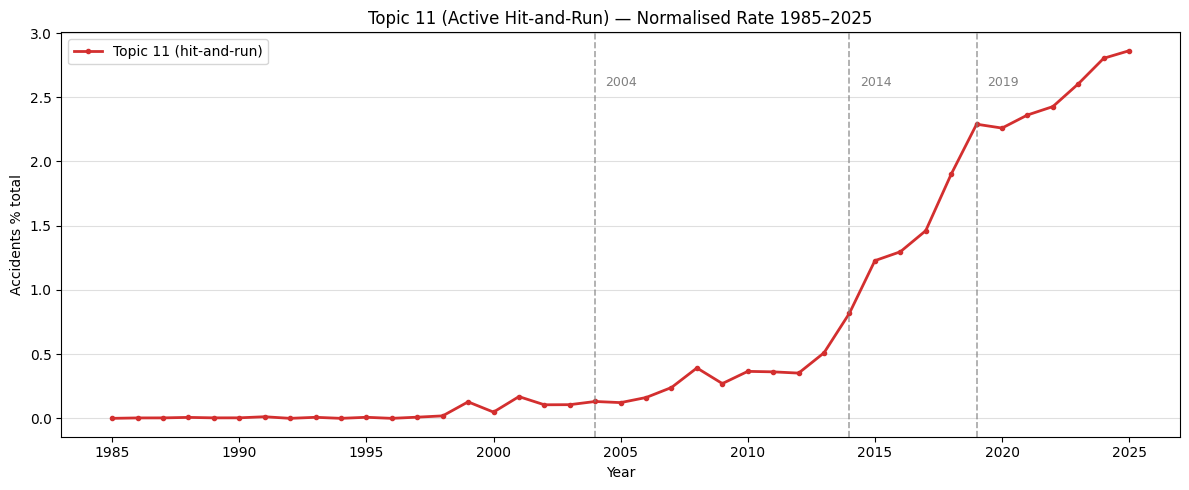

      total  count  rate_per_10k
year                            
1985  30743    0.0      0.000000
1986  30614    1.0      0.003266
1987  28202    1.0      0.003546
1988  27237    2.0      0.007343
1989  26559    1.0      0.003765
1990  25182    1.0      0.003971
1991  24096    3.0      0.012450
1992  24267    0.0      0.000000
1993  24758    2.0      0.008078
1994  23719    0.0      0.000000
1995  24302    2.0      0.008230
1996  23363    0.0      0.000000
1997  22013    2.0      0.009086
1998  20856    4.0      0.019179
1999  21822   28.0      0.128311
2000  22620   11.0      0.048630
2001  21862   37.0      0.169243
2002  21793   23.0      0.105538
2003  21615   23.0      0.106408
2004  21339   28.0      0.131215
2005  19601   24.0      0.122443
2006  20358   33.0      0.162098
2007  21244   51.0      0.240068
2008  19883   78.0      0.392295
2009  18099   49.0      0.270733
2010  16680   61.0      0.365707
2011  16575   60.0      0.361991
2012  16752   59.0      0.352197
2013  1685

In [18]:
# ── Topic 11 | 1. Temporal trend normalised per 10,000 accidents ─────────────────
import os
os.makedirs("results/topic11", exist_ok=True)

t11 = df_acc[df_acc["assigned_topic"] == 11].copy()

annual_total = df_acc.groupby("year").size().rename("total")
annual_t11   = t11.groupby("year").size().rename("count")
annual       = pd.concat([annual_total, annual_t11], axis=1).fillna(0)
annual["rate_per_10k"] = annual["count"] / annual["total"] * 100

years = annual.index.values.astype(int)
rates = annual["rate_per_10k"].values

# Changepoint detection (PELT / rbf)
signal = rates.reshape(-1, 1)
algo   = rpt.Pelt(model="rbf").fit(signal)
cps    = algo.predict(pen=2)
cp_years = [years[i - 1] for i in cps if 0 < i < len(years)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(years, rates, color="#D32F2F", linewidth=2, marker="o", markersize=3,
        label="Topic 11 (hit-and-run)")
for y in cp_years:
    ax.axvline(y, color="grey", linestyle="--", linewidth=1.2, alpha=0.7)
    ax.text(y + 0.4, rates.max() * 0.93, str(y), fontsize=9, color="grey", va="top")
ax.set_xlabel("Year")
ax.set_ylabel("Accidents % total")
ax.set_title("Topic 11 (Active Hit-and-Run) — Normalised Rate 1985–2025")
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("results/topic11/temporal_normalised.png", dpi=150)
plt.show()

print(annual.to_string())
print(f"\nChangepoint years detected: {cp_years}")


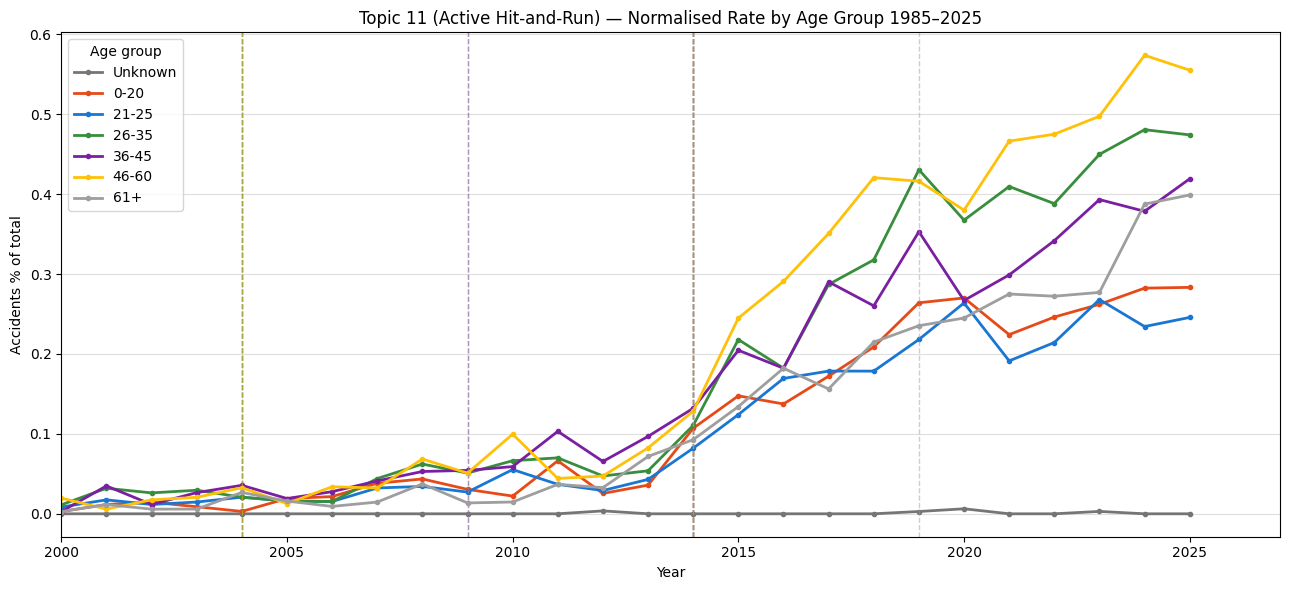

   Unknown: changepoints = []
      0-20: changepoints = [2004, 2014]
     21-25: changepoints = [2004, 2014]
     26-35: changepoints = [2004, 2014]
     36-45: changepoints = [2009, 2014]
     46-60: changepoints = [2004, 2014]
       61+: changepoints = [2009, 2014, 2019]


In [35]:
# ── Topic 11 | 1. Temporal trend normalised per 10,000 accidents — by age group ──
import os
os.makedirs("results/topic11", exist_ok=True)

AGE_GROUPS = labels
COLORS = {
    "Unknown": "#757575",
    "0-20":    "#E64A19",
    "21-25":   "#1976D2",
    "26-35":   "#388E3C",
    "36-45":   "#7B1FA2",
    "46-60":   "#FFC107",
    "61+":     "#9E9E9E",
}

t11 = df_acc[df_acc["assigned_topic"] == 11].copy()

annual_total = df_acc.groupby("year").size().rename("total")

fig, ax = plt.subplots(figsize=(13, 6))

all_cp_years = {}

for grp in AGE_GROUPS:
    subset = t11[t11["age_group"] == grp]
    annual_grp = subset.groupby("year").size().rename("count")
    annual = pd.concat([annual_total, annual_grp], axis=1).fillna(0)
    annual["rate_per_10k"] = annual["count"] / annual["total"] * 100

    years = annual.index.values.astype(int)
    rates = annual["rate_per_10k"].values

    # Changepoint detection per group
    signal = rates.reshape(-1, 1)
    algo   = rpt.Pelt(model="rbf").fit(signal)
    cps    = algo.predict(pen=2)
    cp_years = [years[i - 1] for i in cps if 0 < i < len(years)]
    all_cp_years[grp] = cp_years

    color = COLORS[grp]
    ax.plot(years, rates, color=color, linewidth=2, marker="o", markersize=3,
            label=grp)
    for y in cp_years:
        ax.axvline(y, color=color, linestyle="--", linewidth=1.0, alpha=0.5)

ax.set_xlabel("Year")
ax.set_ylabel("Accidents % of total")
ax.set_title("Topic 11 (Active Hit-and-Run) — Normalised Rate by Age Group 1985–2025")
ax.legend(title="Age group", framealpha=0.8)
ax.grid(axis="y", alpha=0.4)
ax.set_xlim(2000, ax.get_xlim()[1])

plt.tight_layout()
plt.savefig("results/topic11/temporal_normalised_by_age.png", dpi=150)
plt.show()

for grp, cps in all_cp_years.items():
    print(f"{grp:>10}: changepoints = {cps}")

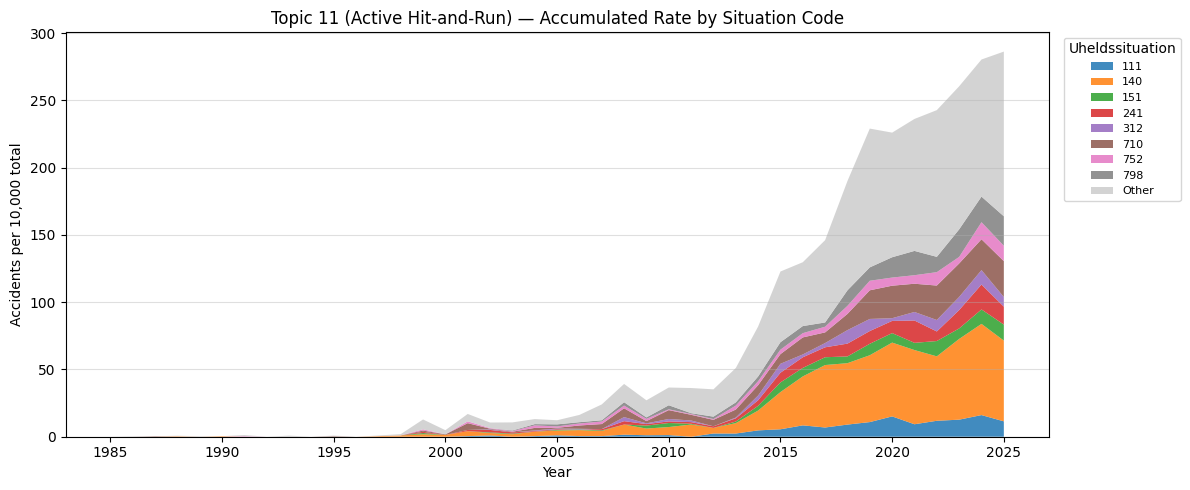

In [30]:
# ── Topic 11 | 1. Temporal trend normalised per 10,000 accidents ─────────────────
import os
os.makedirs("results/topic11", exist_ok=True)

t11 = df_acc[df_acc["assigned_topic"] == 11].copy()

annual_total = df_acc.groupby("year").size().rename("total")

# Top 8 situation codes by frequency within topic 11
top_codes = (
    t11["encoded_accident_situation"]
    .value_counts()
    .head(8)
    .index.tolist()
)

# Rate per 10,000 for each top code per year
code_annual = (
    t11[t11["encoded_accident_situation"].isin(top_codes)]
    .groupby(["year", "encoded_accident_situation"])
    .size()
    .unstack(fill_value=0)
    .div(annual_total, axis=0)
    * 10_000
).fillna(0)

# Other: all codes not in top 8
other_annual = (
    t11[~t11["encoded_accident_situation"].isin(top_codes)]
    .groupby("year")
    .size()
    .reindex(annual_total.index, fill_value=0)
    .div(annual_total)
    * 10_000
).fillna(0)

code_annual.columns = [
    str(int(c)) if not isinstance(c, str) else c
    for c in code_annual.columns
]
code_annual = code_annual.reindex(annual_total.index, fill_value=0)
code_annual["Other"] = other_annual

palette = list(plt.cm.tab10.colors[:8]) + ["#cccccc"]
years = code_annual.index.values.astype(int)

fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(
    years,
    [code_annual[c].values for c in code_annual.columns],
    labels=code_annual.columns,
    colors=palette,
    alpha=0.85,
)

ax.set_xlabel("Year")
ax.set_ylabel("Accidents per 10,000 total")
ax.set_title("Topic 11 (Active Hit-and-Run) — Accumulated Rate by Situation Code")
ax.legend(title="Uheldssituation", bbox_to_anchor=(1.01, 1), loc="upper left",
          fontsize=8, framealpha=0.8)
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("results/topic11/temporal_normalised.png", dpi=150, bbox_inches="tight")
plt.show()

In [29]:
# ── Diagnose situation code coverage in Topic 11 — full period vs 2020–2025 ───
t11_recent = t11[t11["year"].between(2019, 2025)]

code_counts_all    = t11["encoded_accident_situation"].value_counts()
code_counts_recent = t11_recent["encoded_accident_situation"].value_counts()

all_codes = code_counts_all.index.union(code_counts_recent.index)

pct_all    = (code_counts_all    / len(t11)        * 100).reindex(all_codes, fill_value=0)
pct_recent = (code_counts_recent / len(t11_recent) * 100).reindex(all_codes, fill_value=0)
cumul_all    = pct_all.sort_values(ascending=False).cumsum()
cumul_recent = pct_recent.sort_values(ascending=False).cumsum()

print(f"Total topic 11 accidents — full period : {len(t11):,}")
print(f"Total topic 11 accidents — 2020–2025   : {len(t11_recent):,}")
print(f"Unique codes — full period : {t11['encoded_accident_situation'].nunique()}")
print(f"Unique codes — 2020–2025   : {t11_recent['encoded_accident_situation'].nunique()}\n")

# Sort by recent frequency
top_codes = code_counts_recent.head(20).index

print(f"{'Code':<12} {'N (all)':>8} {'% (all)':>8} {'Cumul% (all)':>13} "
      f"{'N (recent)':>11} {'% (recent)':>11} {'Cumul% (recent)':>16}")
print("-" * 85)
for code in top_codes:
    n_all    = code_counts_all.get(code, 0)
    n_rec    = code_counts_recent.get(code, 0)
    print(f"{str(code):<12} {n_all:>8,} {pct_all[code]:>7.1f}%  {cumul_all.get(code, 0):>11.1f}%"
          f"  {n_rec:>10,} {pct_recent[code]:>10.1f}%  {cumul_recent.get(code, 0):>14.1f}%")

Total topic 11 accidents — full period : 5,514
Total topic 11 accidents — 2020–2025   : 3,639
Unique codes — full period : 75
Unique codes — 2020–2025   : 72

Code          N (all)  % (all)  Cumul% (all)  N (recent)  % (recent)  Cumul% (recent)
-------------------------------------------------------------------------------------
140             1,255    22.8%         22.8%         816       22.4%            22.4%
710               516     9.4%         32.1%         344        9.5%            31.9%
798               324     5.9%         38.0%         239        6.6%            38.4%
241               278     5.0%         43.0%         181        5.0%            43.4%
111               268     4.9%         47.9%         180        4.9%            48.4%
151               199     3.6%         51.5%         130        3.6%            51.9%
751               161     2.9%         61.1%         129        3.5%            55.5%
752               191     3.5%         55.0%         121        3.3

In [30]:
corpus_codes = df_acc["encoded_accident_situation"].value_counts(normalize=True)
t11_codes = df_acc[df_acc["assigned_topic"] == 11]["encoded_accident_situation"].value_counts(normalize=True)

for code in [140, 710, 798, 241, 111]:
    t11_share = t11_codes.get(code, 0)
    corp_share = corpus_codes.get(code, 0)
    lift = t11_share / corp_share if corp_share > 0 else float("nan")
    print(f"Code {code}: T11={t11_share:.3f}, Corpus={corp_share:.3f}, Lift={lift:.3f}")

Code 140: T11=0.227, Corpus=0.106, Lift=2.145
Code 710: T11=0.094, Corpus=0.045, Lift=2.058
Code 798: T11=0.058, Corpus=0.018, Lift=3.259
Code 241: T11=0.050, Corpus=0.031, Lift=1.604
Code 111: T11=0.048, Corpus=0.021, Lift=2.249


In [53]:
print([c for c in df_acc.columns if 'flugt' in c.lower() or 'ukendt' in c.lower()])

[]


Total Topic 11 accidents                    : 5,572
Contains 'fuh-flugt'  (hyphen)              : 1,411  (25.3%)
Contains 'fuh flugt'  (space)               : 1,896  (34.0%)
Contains either form                        : 3,305  (59.3%)
Contains neither                            : 2,267  (40.7%)


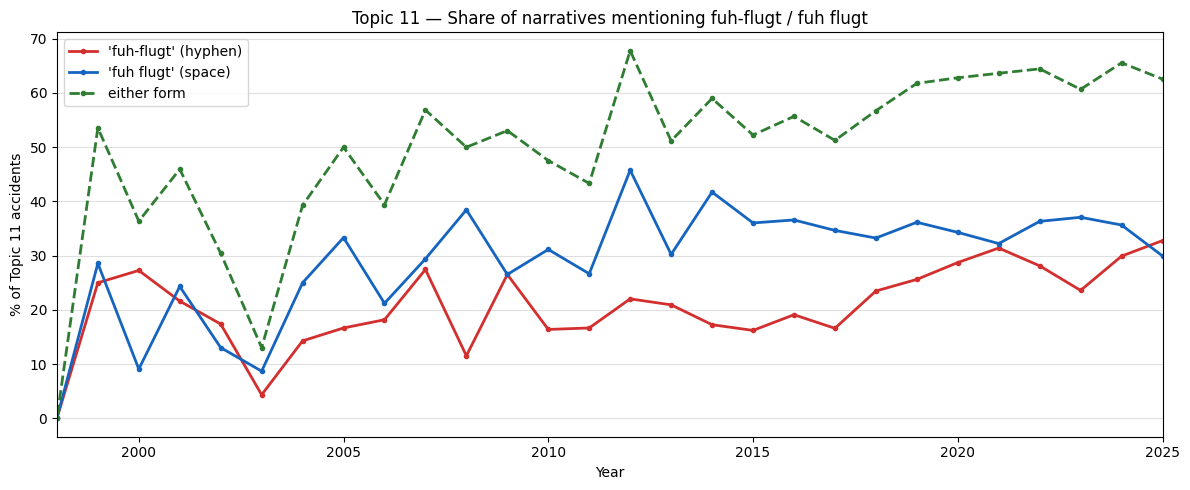


── 3 examples: 'fuh-flugt' (hyphen) ──
  [2018] FUH-flugt. Part 1, personbil, kørte ad Stadionvej mod øst, hvor man i krydset med Nordre Ringvej påkørte part 2, cyklist, der cyklede i sydgående retning ad Nordre Ringvej. Part 1 var flygtet fra sted

  [2022] FUH-FLUGT. Part 2, personbil  kørte i sydgående retning på kørebanen ad Nymarksvej. Part 1 kassebil, kørte i nordgående retning ad Nymarksvej. Part 1's højre side af kassenvognen kørte sammen med part

  [2025] Fuh-flugt - Polmedia. Part 1, personbil, kørte ad Falkoner Allé i sydlig retning, og ramte med højre sidespejl part 2's venstre sidespejl. Part 2, personbil, var parkeret ud for Falkoner Allé 63, og b

── 3 examples: 'fuh flugt' (space) ──
  [2022] FUH flugt: ANM oplyste, at hans personbil i går aftes var blevet påkørt på overstående parkeringsplads, hvor bilen holdt parkeret. Skade i form af ridser, buler og bakkamera. Ejer af Vingaard på overs

  [2018] FUH flugt - part 2 kørte i østlig retning mod Horsens ad Østerhåbsall

In [34]:
t11 = df_acc[df_acc["assigned_topic"] == 11].copy()

t11["has_fuh_flugt"]       = t11["police_narrative"].str.contains(r"fuh-flugt",  case=False, na=False)
t11["has_fuh_space_flugt"] = t11["police_narrative"].str.contains(r"fuh\s+flugt", case=False, na=False)
t11["has_either"]          = t11["has_fuh_flugt"] | t11["has_fuh_space_flugt"]

n = len(t11)
print(f"Total Topic 11 accidents                    : {n:,}")
print(f"Contains 'fuh-flugt'  (hyphen)              : {t11['has_fuh_flugt'].sum():,}  ({t11['has_fuh_flugt'].mean()*100:.1f}%)")
print(f"Contains 'fuh flugt'  (space)               : {t11['has_fuh_space_flugt'].sum():,}  ({t11['has_fuh_space_flugt'].mean()*100:.1f}%)")
print(f"Contains either form                        : {t11['has_either'].sum():,}  ({t11['has_either'].mean()*100:.1f}%)")
print(f"Contains neither                            : {(~t11['has_either']).sum():,}  ({(~t11['has_either']).mean()*100:.1f}%)")

# ── Annual percentage plot ────────────────────────────────────────────────────
annual_t11   = t11.groupby("year").size().rename("t11_count")
annual_flags = t11.groupby("year")[["has_fuh_flugt", "has_fuh_space_flugt", "has_either"]].sum()
annual = pd.concat([annual_t11, annual_flags], axis=1).fillna(0)
annual["pct_fuh_flugt"]       = annual["has_fuh_flugt"]       / annual["t11_count"] * 100
annual["pct_fuh_space_flugt"] = annual["has_fuh_space_flugt"] / annual["t11_count"] * 100
annual["pct_either"]          = annual["has_either"]          / annual["t11_count"] * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(annual.index, annual["pct_fuh_flugt"],
        color="#D32F2F", linewidth=2, marker="o", markersize=3,
        label="'fuh-flugt' (hyphen)")
ax.plot(annual.index, annual["pct_fuh_space_flugt"],
        color="#1565C0", linewidth=2, marker="o", markersize=3,
        label="'fuh flugt' (space)")
ax.plot(annual.index, annual["pct_either"],
        color="#2E7D32", linewidth=2, marker="o", markersize=3,
        linestyle="--", label="either form")
ax.set_ylabel("% of Topic 11 accidents")
ax.set_xlabel("Year")
ax.set_title("Topic 11 — Share of narratives mentioning fuh-flugt / fuh flugt")
ax.legend()
ax.grid(axis="y", alpha=0.4)
ax.set_xlim(1998, 2025)
plt.tight_layout()
plt.savefig("results/topic11/fuh_flugt_pct.png", dpi=150)
plt.show()

print("\n── 3 examples: 'fuh-flugt' (hyphen) ──")
for i, row in t11[t11["has_fuh_flugt"]].sample(3, random_state=42).iterrows():
    print(f"  [{row['year']}] {str(row['police_narrative'])[:200]}\n")

print("── 3 examples: 'fuh flugt' (space) ──")
for i, row in t11[t11["has_fuh_space_flugt"]].sample(3, random_state=42).iterrows():
    print(f"  [{row['year']}] {str(row['police_narrative'])[:200]}\n")

print("── 3 examples: neither ──")
for i, row in t11[~t11["has_either"]].sample(3, random_state=42).iterrows():
    print(f"  [{row['year']}] {str(row['police_narrative'])[:200]}\n")

Total Topic 11 accidents                    : 5,514
Contains 'fuh-flugt'  (hyphen)              : 1,400  (25.4%)
Contains 'fuh flugt'  (space)               : 1,886  (34.2%)
Contains either form                        : 3,284  (59.6%)
Contains neither                            : 2,230  (40.4%)


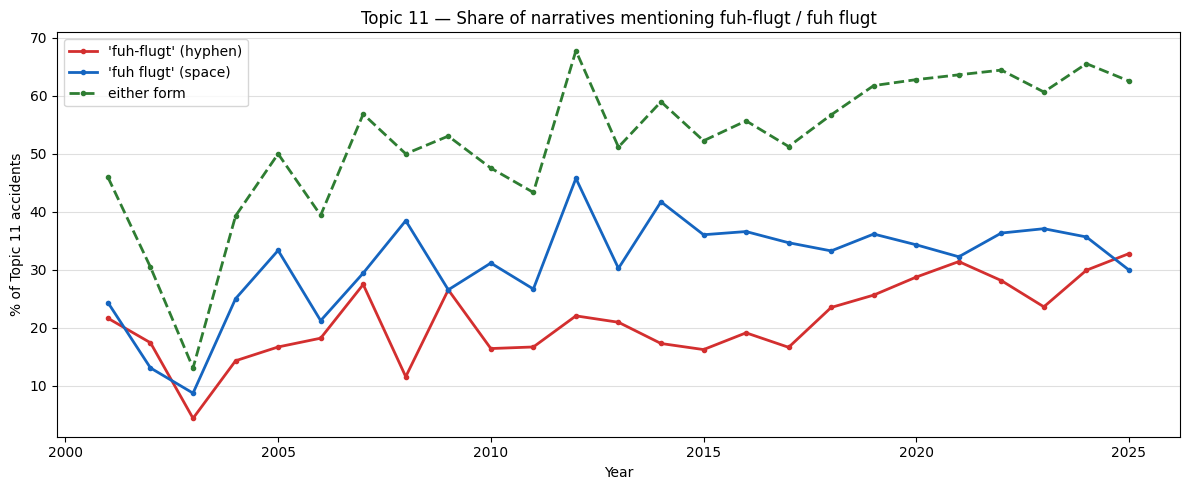


── 3 examples: 'fuh-flugt' (hyphen) ──
  [2021] Fuh-flugt. Part 2 gik på gågaden ude foran Føtex. Part 1 kom kørende mod syd på sin scooter med høj fart, påkørte manden, og kørte videre uden at standse. Part 2 pådrog sig en fraktur på højre arm, og

  [2021] FUH-Flugt. Part 1 havde bakke ind i fronten af part 2, men få skader til følge på kofangeren og nummerpladen. Part 1 kørte med det samme fra stedet, uden at tage kontakt til part 2. Han kørte ad Musvå

  [2014] FUH-flugt: Mercedes-Benz Sprinter, årg. 07, rød, varebil påkørte anmelders bil, på P-plads hvor venstre fordør og skærm blev ridset/bulet, sidespejl afrevet og blev derefter banket op i bilens A-stolp

── 3 examples: 'fuh flugt' (space) ──
  [2015] FUH flugt. ANM oplyste, at hun netop havde set en pige blive kørt ned på sin cykel. Bilisten fortsat videre uden at give sig til kende, billisten en ældre dame i en grå Peugeot,, parkerede ved Føtex. 

  [2016] FUH flugt. Knallert med 2 personer påkører personbil, BD99999, med på

In [28]:
t11 = df_acc[
    (df_acc["assigned_topic"] == 11) &
    (df_acc["year"] > 2000)
].copy()

t11["has_fuh_flugt"]       = t11["police_narrative"].str.contains(r"fuh-flugt",  case=False, na=False)
t11["has_fuh_space_flugt"] = t11["police_narrative"].str.contains(r"fuh\s+flugt", case=False, na=False)
t11["has_either"]          = t11["has_fuh_flugt"] | t11["has_fuh_space_flugt"]

n = len(t11)
print(f"Total Topic 11 accidents                    : {n:,}")
print(f"Contains 'fuh-flugt'  (hyphen)              : {t11['has_fuh_flugt'].sum():,}  ({t11['has_fuh_flugt'].mean()*100:.1f}%)")
print(f"Contains 'fuh flugt'  (space)               : {t11['has_fuh_space_flugt'].sum():,}  ({t11['has_fuh_space_flugt'].mean()*100:.1f}%)")
print(f"Contains either form                        : {t11['has_either'].sum():,}  ({t11['has_either'].mean()*100:.1f}%)")
print(f"Contains neither                            : {(~t11['has_either']).sum():,}  ({(~t11['has_either']).mean()*100:.1f}%)")

# ── Annual percentage plot ────────────────────────────────────────────────────
annual_t11   = t11.groupby("year").size().rename("t11_count")
annual_flags = t11.groupby("year")[["has_fuh_flugt", "has_fuh_space_flugt", "has_either"]].sum()
annual = pd.concat([annual_t11, annual_flags], axis=1).fillna(0)
annual["pct_fuh_flugt"]       = annual["has_fuh_flugt"]       / annual["t11_count"] * 100
annual["pct_fuh_space_flugt"] = annual["has_fuh_space_flugt"] / annual["t11_count"] * 100
annual["pct_either"]          = annual["has_either"]          / annual["t11_count"] * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(annual.index, annual["pct_fuh_flugt"],
        color="#D32F2F", linewidth=2, marker="o", markersize=3,
        label="'fuh-flugt' (hyphen)")
ax.plot(annual.index, annual["pct_fuh_space_flugt"],
        color="#1565C0", linewidth=2, marker="o", markersize=3,
        label="'fuh flugt' (space)")
ax.plot(annual.index, annual["pct_either"],
        color="#2E7D32", linewidth=2, marker="o", markersize=3,
        linestyle="--", label="either form")
ax.set_ylabel("% of Topic 11 accidents")
ax.set_xlabel("Year")
ax.set_title("Topic 11 — Share of narratives mentioning fuh-flugt / fuh flugt")
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("results/topic11/fuh_flugt_pct.png", dpi=150)
plt.show()

print("\n── 3 examples: 'fuh-flugt' (hyphen) ──")
for i, row in t11[t11["has_fuh_flugt"]].sample(3, random_state=42).iterrows():
    print(f"  [{row['year']}] {str(row['police_narrative'])[:200]}\n")

print("── 3 examples: 'fuh flugt' (space) ──")
for i, row in t11[t11["has_fuh_space_flugt"]].sample(3, random_state=42).iterrows():
    print(f"  [{row['year']}] {str(row['police_narrative'])[:200]}\n")

print("── 3 examples: neither ──")
for i, row in t11[~t11["has_either"]].sample(3, random_state=42).iterrows():
    print(f"  [{row['year']}] {str(row['police_narrative'])[:200]}\n")

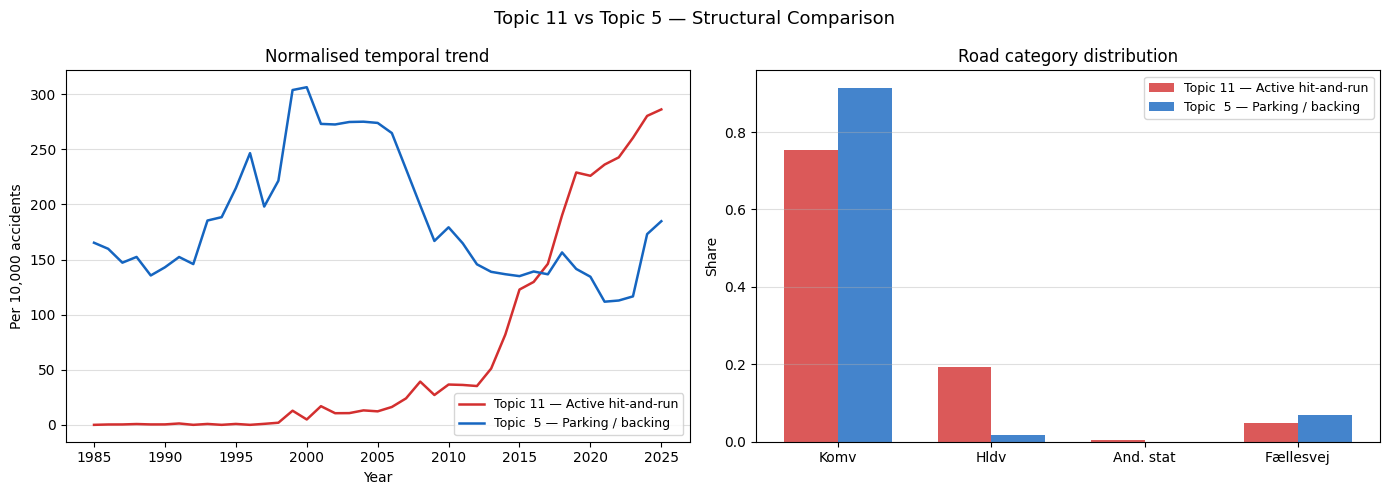


Topic 11 — Active hit-and-run  (n=5,572)
  VEJKATEGORI: {'Komv': 0.754, 'Hldv': 0.193, 'Fællesvej': 0.048, 'And. stat': 0.004}
  UHELDSART  : {3.0: 0.644, 4.0: 0.142, 1.0: 0.107, 2.0: 0.106}

Topic  5 — Parking / backing  (n=16,541)
  VEJKATEGORI: {'Komv': 0.914, 'Fællesvej': 0.069, 'Hldv': 0.018, 'And. stat': 0.0}
  UHELDSART  : {3.0: 0.538, 4.0: 0.405, 2.0: 0.045, 1.0: 0.012}


In [20]:
# ── Topic 11 | 2. Comparison against Topic 5 ────────────────────────────
# Topic  5 = parkeret / holdt parkeret / bakkede  (parking / backing hit)
# Topic 11 = flugt / flygtet                      (active hit-and-run, fled scene)

COMPARE = {
    11: ("Topic 11 — Active hit-and-run", "#D32F2F"),
     5: ("Topic  5 — Parking / backing",  "#1565C0"),
}

annual_total = df_acc.groupby("year").size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Topic 11 vs Topic 5 — Structural Comparison", fontsize=13)

# ① Temporal trends
for tid, (label, colour) in COMPARE.items():
    ann  = df_acc[df_acc["assigned_topic"] == tid].groupby("year").size()
    rate = (ann / annual_total * 10_000).fillna(0)
    axes[0].plot(rate.index, rate.values, color=colour, linewidth=1.8, label=label)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Per 10,000 accidents")
axes[0].set_title("Normalised temporal trend")
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", alpha=0.4)

# ② Road-category distribution
cat_order = ["Komv", "Hldv", "And. stat", "Fællesvej"]
x = np.arange(len(cat_order))
width = 0.35
for i, (tid, (label, colour)) in enumerate(COMPARE.items()):
    sub = df_acc[df_acc["assigned_topic"] == tid]
    vc  = sub["VEJKATEGORI"].value_counts(normalize=True).reindex(cat_order, fill_value=0)
    axes[1].bar(x + (i - 0.5) * width, vc.values, width,
                label=label, color=colour, alpha=0.80)
axes[1].set_xticks(x)
axes[1].set_xticklabels(cat_order)
axes[1].set_ylabel("Share")
axes[1].set_title("Road category distribution")
axes[1].legend(fontsize=9)
axes[1].grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("results/topic11/comparison_topic5.png", dpi=150)
plt.show()

# Key stats printout
for tid, (label, _) in COMPARE.items():
    sub = df_acc[df_acc["assigned_topic"] == tid]
    print(f"\n{label}  (n={len(sub):,})")
    print("  VEJKATEGORI:", sub["VEJKATEGORI"].value_counts(normalize=True).round(3).to_dict())
    if "UHELDSART" in df_acc.columns:
        print("  UHELDSART  :", sub["UHELDSART"].value_counts(normalize=True).head(5).round(3).to_dict())


Geographic distribution (Topic 11 vs Corpus):
               Topic 11  Corpus   lift
kommune_group                         
Hovedstad        0.4015  0.2874  1.397
Provinsby        0.2266  0.2303  0.984
Storby           0.1315  0.1185  1.109
Land             0.1284  0.2167  0.593
Opland           0.1120  0.1472  0.761


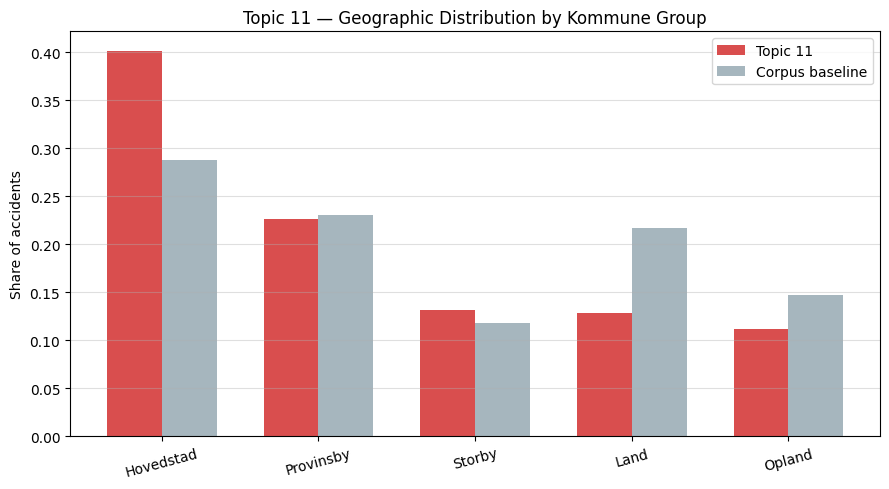

In [21]:
# ── Topic 11 | 3. Geographic distribution by kommune_group ──────────────
t11 = df_acc[df_acc["assigned_topic"] == 11].copy()

t11_geo    = t11["kommune_group"].value_counts(normalize=True).rename("Topic 11")
corpus_geo = df_acc["kommune_group"].value_counts(normalize=True).rename("Corpus")
geo_cmp    = pd.concat([t11_geo, corpus_geo], axis=1).fillna(0)
geo_cmp["lift"] = (geo_cmp["Topic 11"] / geo_cmp["Corpus"].replace(0, np.nan)).round(3)
geo_cmp    = geo_cmp.sort_values("Topic 11", ascending=False)

print("Geographic distribution (Topic 11 vs Corpus):")
print(geo_cmp.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(geo_cmp))
width = 0.35
ax.bar(x - width/2, geo_cmp["Topic 11"], width,
       label="Topic 11",        color="#D32F2F", alpha=0.85)
ax.bar(x + width/2, geo_cmp["Corpus"],   width,
       label="Corpus baseline", color="#90A4AE", alpha=0.80)
ax.set_xticks(x)
ax.set_xticklabels(geo_cmp.index, rotation=15)
ax.set_ylabel("Share of accidents")
ax.set_title("Topic 11 — Geographic Distribution by Kommune Group")
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("results/topic11/geo_kommune_group.png", dpi=150)
plt.show()


In [24]:
# ── Topic 11 | 4. Severity comparison vs corpus baseline ────────────────
from scipy import stats as sp_stats

print("UHELDSART value counts (full corpus):")
print(df_acc["report_category"].value_counts().head(15))
print()

# Build fatal flag — numeric code 1 = dræbt in most VD encodings; text fallback
if pd.api.types.is_numeric_dtype(df_acc["report_category"]):
    df_acc["_fatal"] = (df_acc["report_category"] == 1).astype(int)
    print("Using numeric UHELDSART == 1 as fatal indicator")
else:
    fatal_vals = [v for v in df_acc["report_category"].dropna().unique()
                  if any(k in str(v).lower() for k in ["drab", "dræbt", "drbt"])]
    print(f"String UHELDSART — fatal values identified: {fatal_vals}")
    if fatal_vals:
        df_acc["_fatal"] = df_acc["report_category"].isin(fatal_vals).astype(int)
    else:
        alv_col = "ANTAL_ALV_TILSKADEKOMNE"
        df_acc["_fatal"] = (df_acc[alv_col].fillna(0) > 0).astype(int) if alv_col in df_acc.columns else 0
        print("Fallback: ANTAL_ALV_TILSKADEKOMNE > 0 as severe-injury proxy")

t11    = df_acc[df_acc["assigned_topic"] == 11]
others = df_acc[df_acc["assigned_topic"] != 11]

f11  = int(t11["_fatal"].sum());   n11  = len(t11)
foth = int(others["_fatal"].sum()); noth = len(others)

r11  = f11  / n11
roth = foth / noth
print(f"\nTopic 11 rate : {r11:.4f}  ({r11*100:.2f}%,  n={n11:,})")
print(f"Corpus rest   : {roth:.4f}  ({roth*100:.2f}%,  n={noth:,})")

ct = np.array([[f11, n11 - f11], [foth, noth - foth]])
chi2, p, dof, _ = sp_stats.chi2_contingency(ct)
print(f"\nChi-square: {chi2:.3f},  p = {p:.4f},  df = {dof}")
print("→ " + ("Statistically significant (p < 0.05)" if p < 0.05 else "NOT significant (p ≥ 0.05)"))

df_acc.drop(columns=["_fatal"], inplace=True)


UHELDSART value counts (full corpus):
report_category
Anmsuh    343337
Pskduh    239606
Exuh      235470
Mskduh     72127
Name: count, dtype: int64

String UHELDSART — fatal values identified: []
Fallback: ANTAL_ALV_TILSKADEKOMNE > 0 as severe-injury proxy

Topic 11 rate : 0.0581  (5.81%,  n=5,572)
Corpus rest   : 0.1553  (15.53%,  n=884,968)

Chi-square: 398.679,  p = 0.0000,  df = 1
→ Statistically significant (p < 0.05)


Distinct UHELDSSITUATION codes in Topic 11: 52

Top 20 codes (count):
encoded_accident_situation
140    1267
710     521
798     324
241     280
111     268
151     201
752     194
312     176
242     165
751     161
720     159
410     140
152     134
510     125
270     115
610     110
660     109
520      97
112      80
160      66

Corpus distinct codes: 84


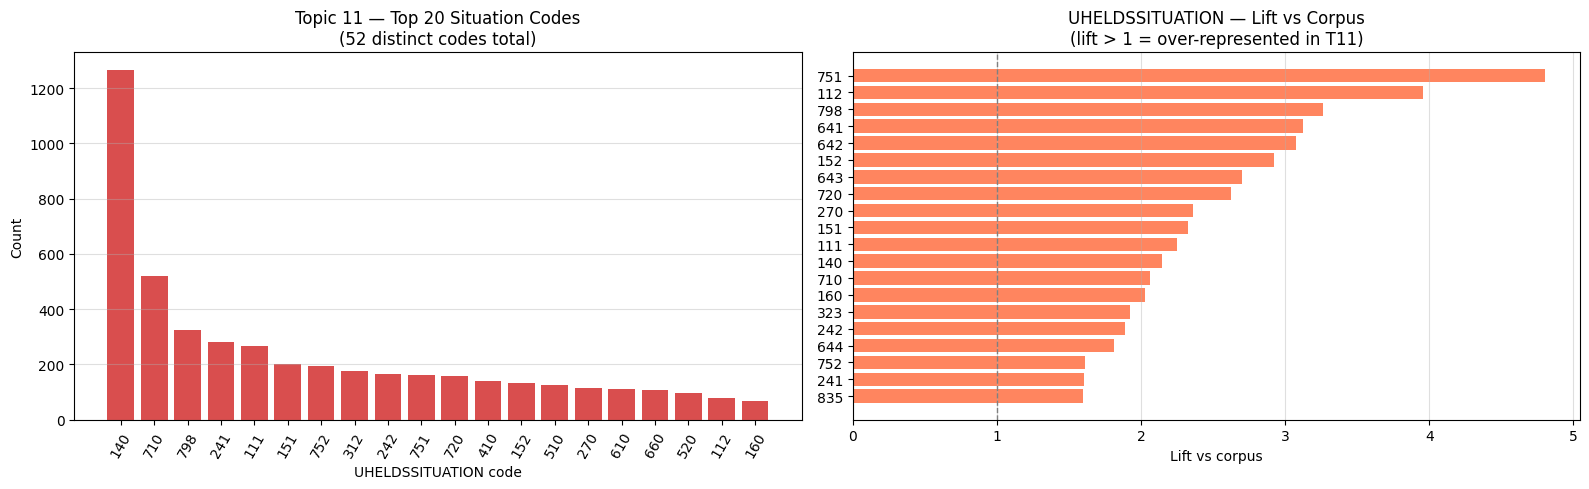

In [22]:
# ── Topic 11 | 5. UHELDSSITUATION spread — proof of invisibility ──────────
t11 = df_acc[df_acc["assigned_topic"] == 11].copy()

sit_counts = t11["encoded_accident_situation"].value_counts()
n_distinct  = sit_counts.nunique()
print(f"Distinct UHELDSSITUATION codes in Topic 11: {n_distinct}")
print("\nTop 20 codes (count):")
print(sit_counts.head(20).to_string())
print(f"\nCorpus distinct codes: {df_acc['encoded_accident_situation'].value_counts().nunique()}")

# Lift vs corpus
t11_share    = t11["encoded_accident_situation"].value_counts(normalize=True)
corpus_share = df_acc["encoded_accident_situation"].value_counts(normalize=True)
lift = (t11_share / corpus_share.reindex(t11_share.index).replace(0, np.nan)
        ).dropna().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top20 = sit_counts.head(20)
axes[0].bar(top20.index.astype(str), top20.values, color="#D32F2F", alpha=0.85)
axes[0].set_xlabel("UHELDSSITUATION code")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Topic 11 — Top 20 Situation Codes\n({n_distinct} distinct codes total)")
axes[0].tick_params(axis="x", rotation=60)
axes[0].grid(axis="y", alpha=0.4)

top20_lift = lift.head(20)
axes[1].barh(top20_lift.index.astype(str)[::-1], top20_lift.values[::-1],
             color="#FF7043", alpha=0.85)
axes[1].axvline(1, color="grey", linestyle="--", linewidth=1)
axes[1].set_xlabel("Lift vs corpus")
axes[1].set_title("UHELDSSITUATION — Lift vs Corpus\n(lift > 1 = over-represented in T11)")
axes[1].grid(axis="x", alpha=0.4)

plt.tight_layout()
plt.savefig("results/topic11/situation_code_spread.png", dpi=150)
plt.show()


In [38]:
t11 = df_acc[df_acc["assigned_topic"] == 11].copy()

prob = t11["probability_main_0_3"].dropna()

print(f"Topic 11 — HDBSCAN assignment confidence (n={len(prob):,})")
print(f"  Mean:    {prob.mean():.3f}")
print(f"  Median:  {prob.median():.3f}")
print(f"  Std:     {prob.std():.3f}")
print(f"  >0.7:    {(prob > 0.7).mean()*100:.1f}%")
print(f"  >0.5:    {(prob > 0.5).mean()*100:.1f}%")
print(f"  <0.3:    {(prob < 0.3).mean()*100:.1f}%")

Topic 11 — HDBSCAN assignment confidence (n=5,572)
  Mean:    0.868
  Median:  1.000
  Std:     0.226
  >0.7:    79.2%
  >0.5:    88.0%
  <0.3:    3.1%


In [39]:
from scipy.stats import chi2_contingency
import numpy as np

t11 = df_acc["assigned_topic"] == 11
corpus = ~t11

categories = ["Anmsuh", "Exuh", "Pskduh", "Mskduh"]
n_tests = len(categories)

print(f"UHELDSART significance tests — Topic 11 vs corpus (Bonferroni n={n_tests})\n")

for cat in categories:
    t11_yes = ((df_acc["report_category"] == cat) & t11).sum()
    t11_no  = (t11).sum() - t11_yes
    corp_yes = ((df_acc["report_category"] == cat) & corpus).sum()
    corp_no  = (corpus).sum() - corp_yes

    table = np.array([[t11_yes, t11_no],
                      [corp_yes, corp_no]])
    chi2, p_raw, dof, _ = chi2_contingency(table)
    p_corr = min(p_raw * n_tests, 1.0)

    t11_share  = t11_yes / t11.sum()
    corp_share = corp_yes / corpus.sum()
    lift = t11_share / corp_share

    print(f"{cat:8s}  T11={t11_share:.3f}  Corpus={corp_share:.3f}  "
          f"lift={lift:.3f}  chi2={chi2:.1f}  p_corr={p_corr:.4f}  "
          f"sig={'True' if p_corr < 0.05 else 'False'}")

UHELDSART significance tests — Topic 11 vs corpus (Bonferroni n=4)

Anmsuh    T11=0.644  Corpus=0.384  lift=1.678  chi2=1583.6  p_corr=0.0000  sig=True
Exuh      T11=0.142  Corpus=0.265  lift=0.537  chi2=427.8  p_corr=0.0000  sig=True
Pskduh    T11=0.107  Corpus=0.270  lift=0.397  chi2=746.6  p_corr=0.0000  sig=True
Mskduh    T11=0.106  Corpus=0.081  lift=1.312  chi2=47.0  p_corr=0.0000  sig=True


ELEMENTART columns already in df_acc: []


/home/s215005/traffic_project/Thesis-traffic-safety/.venv/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Loaded 1,477,567 element rows, cols: ['ELEMENTART']

Element type distribution (Topic 11 vs Corpus):
         Topic 11  Corpus   lift
el_type                         
Pbil       0.7122  0.6468  1.101
Cykl       0.0676  0.0920  0.734
Flugt      0.0392  0.0067  5.887
Last       0.0319  0.0344  0.927
Vbil       0.0305  0.0460  0.663
Fodg       0.0253  0.0346  0.731
Kn30       0.0237  0.0366  0.649
Vare       0.0226  0.0277  0.817
Mc         0.0099  0.0180  0.553
Taxi       0.0053  0.0132  0.401
L_Udr      0.0050  0.0039  1.279
Rbus       0.0049  0.0085  0.577
Abus       0.0049  0.0043  1.138
Sætv       0.0048  0.0076  0.632
Kn45       0.0042  0.0045  0.944


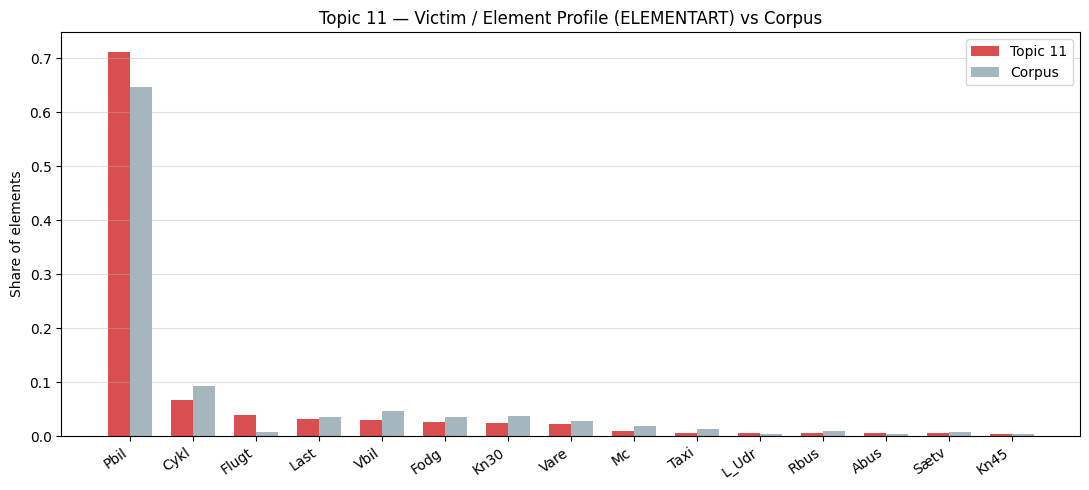

In [23]:
# ── Topic 11 | 6. Victim profile — ELEMENTART from element-level data ────────
# df_el was loaded with only 4 columns in cell 5 above (ELEMENTART dropped).
# We reload here keeping all ELEMENTART columns.

art_in_acc = [c for c in df_acc.columns if "ELEMENTART" in c.upper()]
print(f"ELEMENTART columns already in df_acc: {art_in_acc}")

data_folder_el = "/mnt/raid/data_safetyLLMthesis/data 5"
all_el_art = []
for file in sorted(os.listdir(data_folder_el)):
    if not file.endswith(".xlsx"):
        continue
    path   = os.path.join(data_folder_el, file)
    df_tmp = pd.read_excel(path, header=2)
    df_tmp = df_tmp.rename(columns={"UHELDS_ID": "accident_id"})
    art_cols = [c for c in df_tmp.columns if "ELEMENTART" in c.upper()]
    if not art_cols:
        print(f"  {file}: no ELEMENTART cols found ({list(df_tmp.columns)[:6]}...)")
        continue
    all_el_art.append(df_tmp[["accident_id"] + art_cols])

if all_el_art:
    df_el_art = pd.concat(all_el_art, ignore_index=True)
    art_cols  = [c for c in df_el_art.columns if "ELEMENTART" in c.upper()]
    print(f"Loaded {len(df_el_art):,} element rows, cols: {art_cols}")

    t11_ids   = set(df_acc[df_acc["assigned_topic"] == 11]["accident_id"].dropna().astype(int))
    df_el_t11 = df_el_art[df_el_art["accident_id"].isin(t11_ids)].copy()

    t11_elements = df_el_t11[art_cols].melt(value_name="el_type")["el_type"].dropna()
    all_elements = df_el_art[art_cols].melt(value_name="el_type")["el_type"].dropna()

    t11_vc    = t11_elements.value_counts(normalize=True).rename("Topic 11")
    corpus_vc = all_elements.value_counts(normalize=True).rename("Corpus")
    vc_cmp    = pd.concat([t11_vc, corpus_vc], axis=1).fillna(0)
    vc_cmp["lift"] = (vc_cmp["Topic 11"] / vc_cmp["Corpus"].replace(0, np.nan)).round(3)
    vc_cmp    = vc_cmp.sort_values("Topic 11", ascending=False).head(15)

    print("\nElement type distribution (Topic 11 vs Corpus):")
    print(vc_cmp.round(4).to_string())

    fig, ax = plt.subplots(figsize=(11, 5))
    x = np.arange(len(vc_cmp))
    width = 0.35
    ax.bar(x - width/2, vc_cmp["Topic 11"], width, label="Topic 11", color="#D32F2F", alpha=0.85)
    ax.bar(x + width/2, vc_cmp["Corpus"],   width, label="Corpus",   color="#90A4AE", alpha=0.80)
    ax.set_xticks(x)
    ax.set_xticklabels(vc_cmp.index, rotation=35, ha="right")
    ax.set_ylabel("Share of elements")
    ax.set_title("Topic 11 — Victim / Element Profile (ELEMENTART) vs Corpus")
    ax.legend()
    ax.grid(axis="y", alpha=0.4)
    plt.tight_layout()
    plt.savefig("results/topic11/elementart_profile.png", dpi=150)
    plt.show()
elif art_in_acc:
    print("Using ELEMENTART columns from df_acc:")
    sub = df_acc[df_acc["assigned_topic"] == 11]
    for c in art_in_acc:
        print(f"  {c}:", sub[c].value_counts(normalize=True).head(10).to_dict())
else:
    print("No ELEMENTART data found in either source.")


In [51]:
t11 = df_acc[df_acc["assigned_topic"] == 11].copy()

t11["has_keyword"] = (
    t11["police_narrative"].str.contains(r"fuh-flugt", case=False, na=False) |
    t11["police_narrative"].str.contains(r"fuh\s+flugt", case=False, na=False)
)

annual = t11.groupby("year").agg(
    total=("has_keyword", "count"),
    keyword=("has_keyword", "sum")
)
annual["semantic_only"] = annual["total"] - annual["keyword"]
annual["semantic_only_pct"] = annual["semantic_only"] / annual["total"] * 100

print(annual[["total", "keyword", "semantic_only", "semantic_only_pct"]].to_string())

      total  keyword  semantic_only  semantic_only_pct
year                                                  
1986      1        0              1         100.000000
1987      1        0              1         100.000000
1988      2        1              1          50.000000
1989      1        0              1         100.000000
1990      1        0              1         100.000000
1991      3        0              3         100.000000
1993      2        0              2         100.000000
1995      2        1              1          50.000000
1997      2        0              2         100.000000
1998      4        0              4         100.000000
1999     28       15             13          46.428571
2000     11        4              7          63.636364
2001     37       17             20          54.054054
2002     23        7             16          69.565217
2003     23        3             20          86.956522
2004     28       11             17          60.714286
2005     2

UHELDSART distribution (Topic 11 vs Corpus):
                 Topic 11  Corpus   lift
report_category                         
Anmsuh             0.6443  0.3855  1.671
Exuh               0.1425  0.2644  0.539
Pskduh             0.1071  0.2691  0.398
Mskduh             0.1061  0.0810  1.310


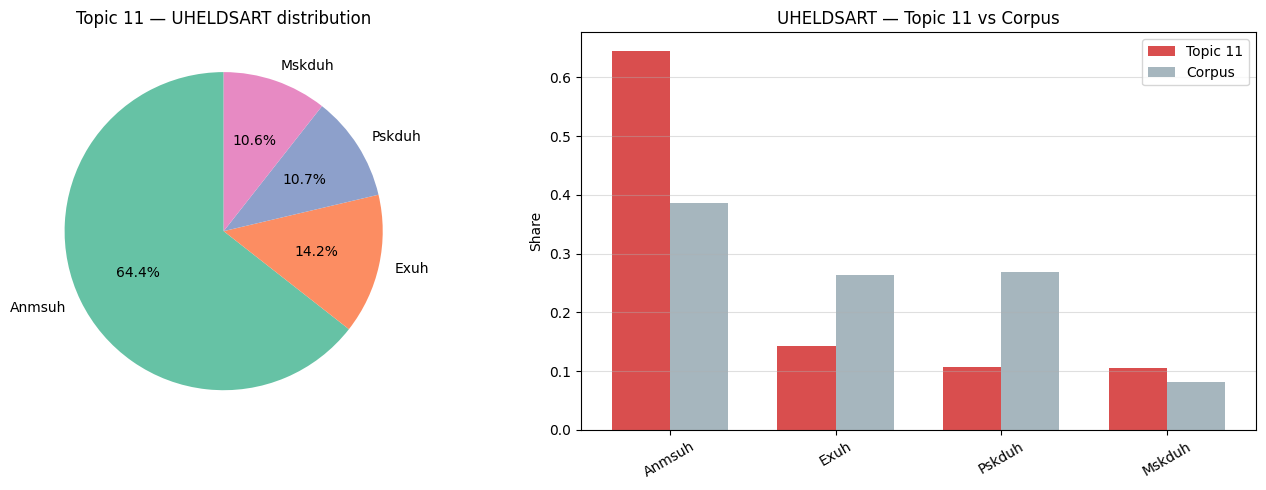

In [48]:
# ── Topic 11 | 7. UHELDSART distribution ─────────────────────────────────────
t11 = df_acc[df_acc["assigned_topic"] == 11].copy()

t11_art    = t11["report_category"].value_counts(normalize=True).rename("Topic 11")
corpus_art = df_acc["report_category"].value_counts(normalize=True).rename("Corpus")
art_cmp    = pd.concat([t11_art, corpus_art], axis=1).fillna(0)
art_cmp["lift"] = (art_cmp["Topic 11"] / art_cmp["Corpus"].replace(0, np.nan)).round(3)
art_cmp    = art_cmp.sort_values("Topic 11", ascending=False)

print("UHELDSART distribution (Topic 11 vs Corpus):")
print(art_cmp.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

art_cmp["Topic 11"].plot.pie(
    ax=axes[0],
    autopct="%1.1f%%",
    colors=list(plt.cm.Set2.colors)[:len(art_cmp)],
    startangle=90,
    ylabel="",
)
axes[0].set_title("Topic 11 — UHELDSART distribution")

x = np.arange(len(art_cmp))
width = 0.35
axes[1].bar(x - width/2, art_cmp["Topic 11"], width, label="Topic 11", color="#D32F2F", alpha=0.85)
axes[1].bar(x + width/2, art_cmp["Corpus"],   width, label="Corpus",   color="#90A4AE", alpha=0.80)
axes[1].set_xticks(x)
axes[1].set_xticklabels(art_cmp.index.astype(str), rotation=30)
axes[1].set_ylabel("Share")
axes[1].set_title("UHELDSART — Topic 11 vs Corpus")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("results/topic11/uheldsart_distribution.png", dpi=150)
plt.show()



UHELDSART distribution — age group: Unknown
                 Topic 11  Corpus   lift
report_category                         
Anmsuh                0.6  0.3569  1.681
Exuh                  0.4  0.4353  0.919
Pskduh                0.0  0.1529  0.000
Mskduh                0.0  0.0549  0.000

UHELDSART distribution — age group: 0-20
                 Topic 11  Corpus   lift
report_category                         
Anmsuh             0.6449  0.3807  1.694
Pskduh             0.1511  0.3875  0.390
Mskduh             0.1066  0.0755  1.412
Exuh               0.0973  0.1563  0.623

UHELDSART distribution — age group: 21-25
                 Topic 11  Corpus   lift
report_category                         
Anmsuh             0.5783  0.4171  1.386
Exuh               0.1544  0.1699  0.909
Mskduh             0.1454  0.0957  1.519
Pskduh             0.1219  0.3173  0.384

UHELDSART distribution — age group: 26-35
                 Topic 11  Corpus   lift
report_category                         
Anmsuh 

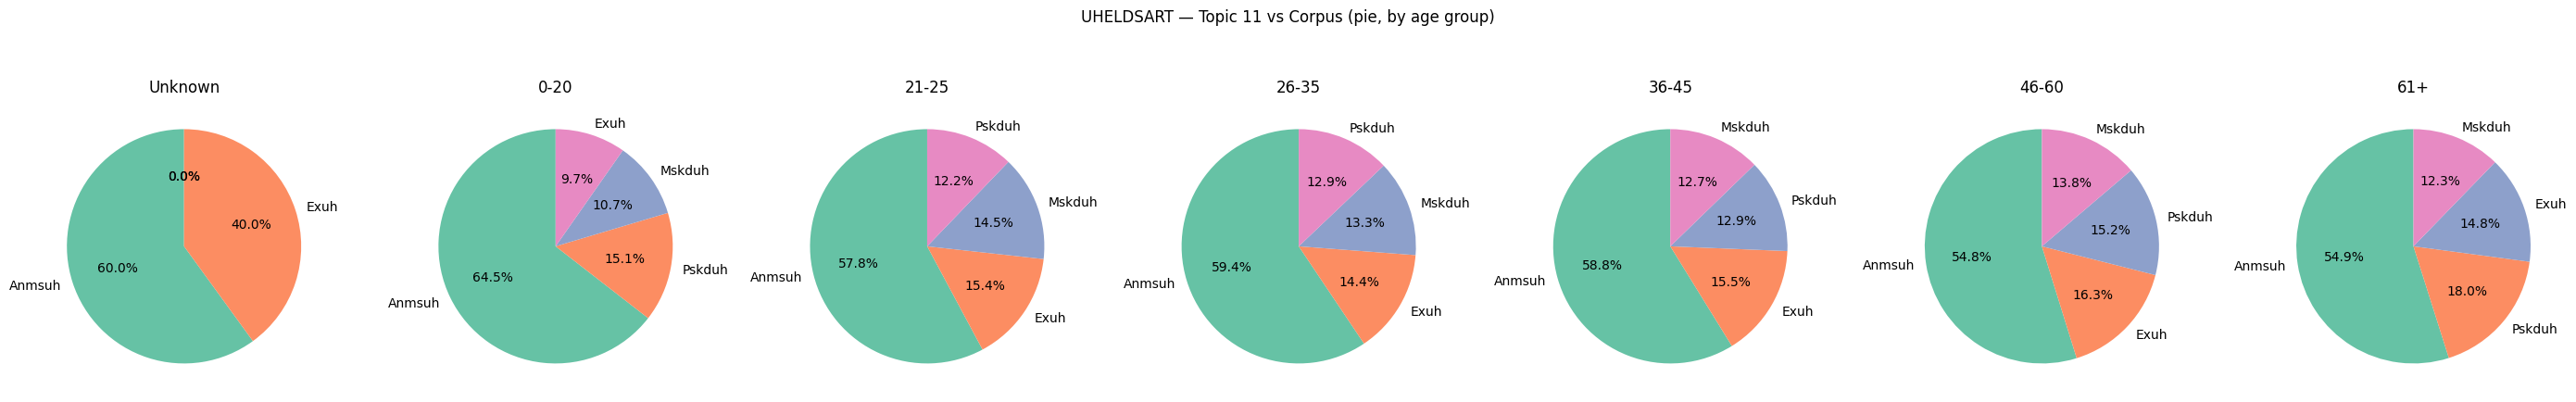

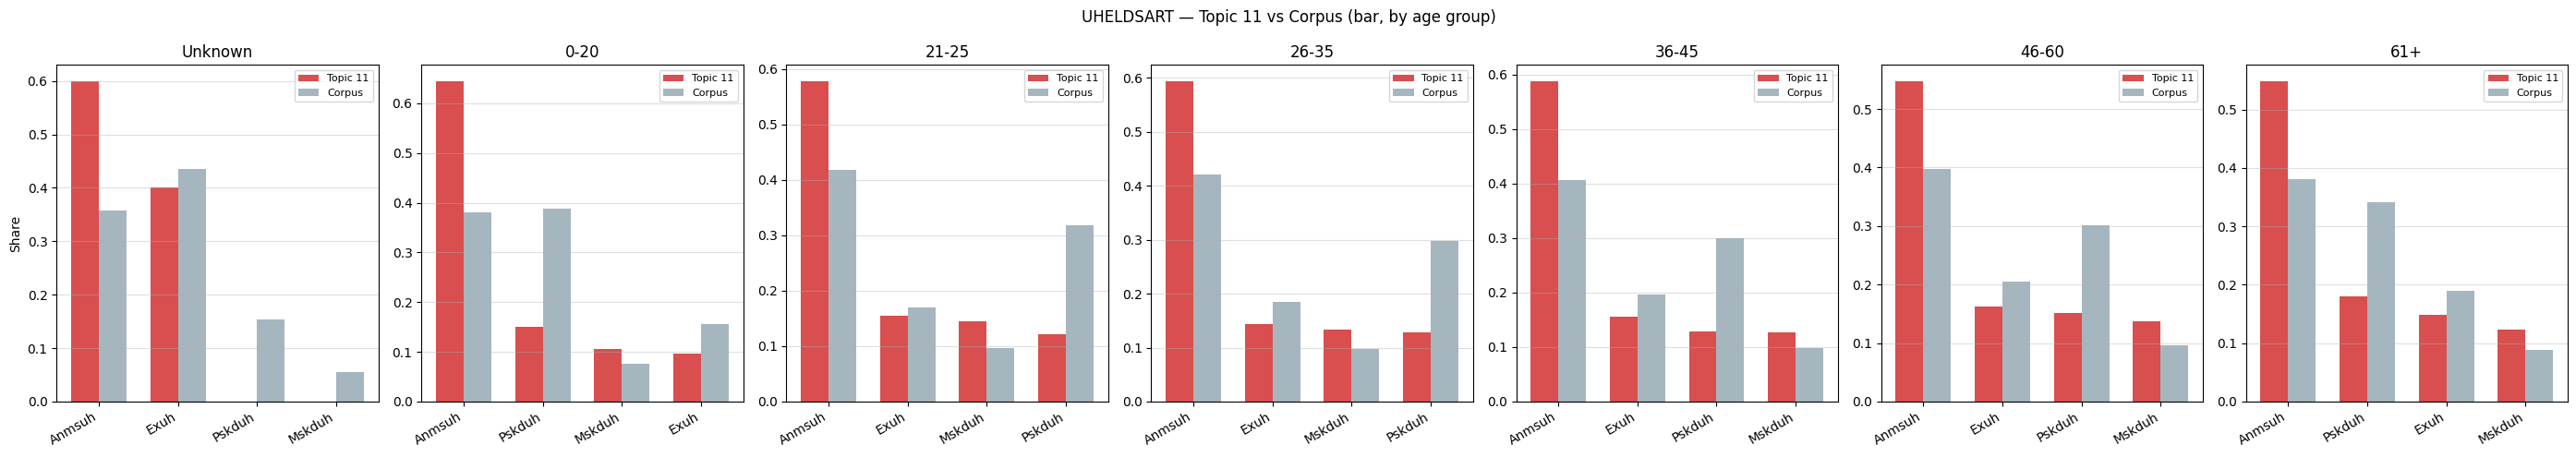

In [36]:
# ── Topic 11 | 7. UHELDSART distribution — per age group ─────────────────────
t11 = df_acc[df_acc["assigned_topic"] == 11].copy()

AGE_GROUPS= labels  # from earlier cell where age groups were defined

fig_pie, axes_pie = plt.subplots(1, len(AGE_GROUPS), figsize=(4 * len(AGE_GROUPS), 5))
fig_bar, axes_bar = plt.subplots(1, len(AGE_GROUPS), figsize=(4 * len(AGE_GROUPS), 5))

for i, grp in enumerate(AGE_GROUPS):
    t11_grp    = t11[t11["age_group"] == grp]
    corpus_grp = df_acc[df_acc["age_group"] == grp]

    t11_art    = t11_grp["report_category"].value_counts(normalize=True).rename("Topic 11")
    corpus_art = corpus_grp["report_category"].value_counts(normalize=True).rename("Corpus")
    art_cmp    = pd.concat([t11_art, corpus_art], axis=1).fillna(0)
    art_cmp["lift"] = (art_cmp["Topic 11"] / art_cmp["Corpus"].replace(0, np.nan)).round(3)
    art_cmp    = art_cmp.sort_values("Topic 11", ascending=False)

    print(f"\nUHELDSART distribution — age group: {grp}")
    print(art_cmp.round(4).to_string())

    # Pie
    art_cmp["Topic 11"].plot.pie(
        ax=axes_pie[i],
        autopct="%1.1f%%",
        colors=list(plt.cm.Set2.colors)[:len(art_cmp)],
        startangle=90,
        ylabel="",
    )
    axes_pie[i].set_title(grp)

    # Bar
    x     = np.arange(len(art_cmp))
    width = 0.35
    axes_bar[i].bar(x - width/2, art_cmp["Topic 11"], width, label="Topic 11", color="#D32F2F", alpha=0.85)
    axes_bar[i].bar(x + width/2, art_cmp["Corpus"],   width, label="Corpus",   color="#90A4AE", alpha=0.80)
    axes_bar[i].set_xticks(x)
    axes_bar[i].set_xticklabels(art_cmp.index.astype(str), rotation=30, ha="right")
    axes_bar[i].set_ylabel("Share" if i == 0 else "")
    axes_bar[i].set_title(grp)
    axes_bar[i].legend(fontsize=8)
    axes_bar[i].grid(axis="y", alpha=0.4)

fig_pie.suptitle("UHELDSART — Topic 11 vs Corpus (pie, by age group)", fontsize=12)
fig_bar.suptitle("UHELDSART — Topic 11 vs Corpus (bar, by age group)", fontsize=12)

fig_pie.tight_layout()
fig_bar.tight_layout()
fig_pie.savefig("results/topic11/uheldsart_pie_by_age.png", dpi=150)
fig_bar.savefig("results/topic11/uheldsart_bar_by_age.png", dpi=150)
plt.show()

In [37]:
from scipy.stats import fisher_exact, chi2_contingency

t11 = df_acc[df_acc["assigned_topic"] == 11].copy()
valid_groups = [g for g in AGE_GROUPS if g in t11["age_group"].unique()]

for grp in valid_groups:
    t11_grp    = t11[t11["age_group"] == grp]
    corpus_grp = df_acc[df_acc["age_group"] == grp]

    t11_art    = t11_grp["report_category"].value_counts().rename("t11")
    corpus_art = corpus_grp["report_category"].value_counts().rename("corpus")
    counts     = pd.concat([t11_art, corpus_art], axis=1).fillna(0).astype(int)

    print(f"\n── Age group: {grp} ──────────────────────────────")
    for cat in counts.index:
        in_t11     = counts.loc[cat, "t11"]
        not_in_t11 = counts.loc[cat, "corpus"] - in_t11

        # skip if corpus count is 0 or negative (t11 > corpus due to fillna edge)
        if not_in_t11 < 0:
            continue

        rest_t11    = counts["t11"].sum()    - in_t11
        rest_corpus = counts["corpus"].sum() - counts.loc[cat, "corpus"]

        table = [[in_t11, not_in_t11],
                 [rest_t11, rest_corpus]]

        # Fisher for small cells, chi2 otherwise
        if min(in_t11, not_in_t11, rest_t11, rest_corpus) < 5:
            _, p = fisher_exact(table, alternative="greater")
            test = "Fisher"
        else:
            _, p, _, _ = chi2_contingency(table)
            test = "chi2"

        t11_share    = in_t11 / counts["t11"].sum() if counts["t11"].sum() > 0 else 0
        corpus_share = counts.loc[cat, "corpus"] / counts["corpus"].sum()
        lift         = (t11_share / corpus_share) if corpus_share > 0 else np.nan

        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        print(f"  {cat:<30} lift={lift:5.2f}  p={p:.4f} {sig}  ({test})")


── Age group: Unknown ──────────────────────────────
  Anmsuh                         lift= 1.68  p=0.2397   (Fisher)
  Exuh                           lift= 0.92  p=0.7155   (Fisher)
  Pskduh                         lift= 0.00  p=1.0000   (Fisher)
  Mskduh                         lift= 0.00  p=1.0000   (Fisher)

── Age group: 0-20 ──────────────────────────────
  Anmsuh                         lift= 1.69  p=0.0000 ***  (chi2)
  Pskduh                         lift= 0.39  p=0.0000 ***  (chi2)
  Mskduh                         lift= 1.41  p=0.0003 ***  (chi2)
  Exuh                           lift= 0.62  p=0.0000 ***  (chi2)

── Age group: 21-25 ──────────────────────────────
  Anmsuh                         lift= 1.39  p=0.0000 ***  (chi2)
  Exuh                           lift= 0.91  p=0.2563   (chi2)
  Mskduh                         lift= 1.52  p=0.0000 ***  (chi2)
  Pskduh                         lift= 0.38  p=0.0000 ***  (chi2)

── Age group: 26-35 ──────────────────────────────
  Anms

Top 30 municipalities — Topic 11 (normalised):
              t11_count  corpus_count  pct_of_local  t11_share  corp_share   lift
UHELDKOMMUNE                                                                     
København        1092.0         41050        2.6602     0.2043      0.1129  1.809
Odense            374.0         17138        2.1823     0.0700      0.0471  1.484
Aarhus            258.0         17171        1.5025     0.0483      0.0472  1.022
Esbjerg           160.0          9047        1.7685     0.0299      0.0249  1.203
Kolding           151.0          8411        1.7953     0.0282      0.0231  1.221
Vejle             139.0          8980        1.5479     0.0260      0.0247  1.053
Frederiksb        127.0          4811        2.6398     0.0238      0.0132  1.795
Horsens           119.0          7133        1.6683     0.0223      0.0196  1.135
Gladsaxe          110.0          4286        2.5665     0.0206      0.0118  1.746
Fredericia        103.0          4333        2.3771

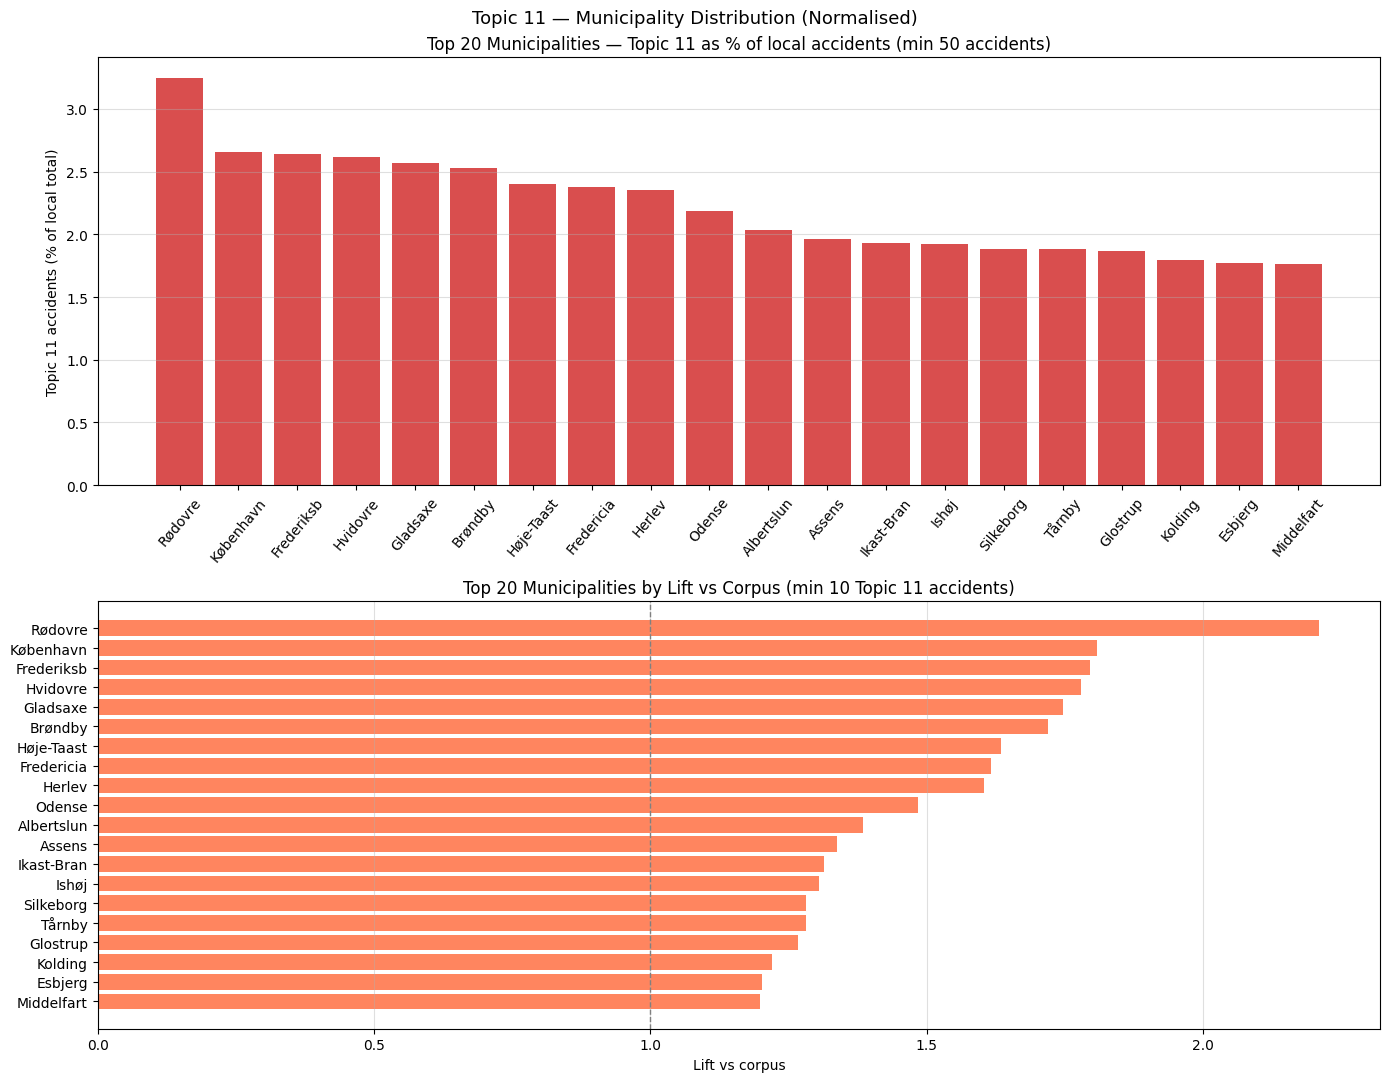


Top 5 municipalities within each kommune_group (% of local accidents):

  Hovedstad (n topic11=2,126, n corpus=96,578):
    Rødovre: 91 / 2799  → 3.25%
    København: 1091 / 40971  → 2.66%
    Frederiksb: 127 / 4799  → 2.65%
    Hvidovre: 83 / 3168  → 2.62%
    Gladsaxe: 110 / 4275  → 2.57%

  Storby (n topic11=705, n corpus=44,882):
    Odense: 373 / 17120  → 2.18%
    Aarhus: 257 / 17143  → 1.50%
    Aalborg: 75 / 10619  → 0.71%

  Provinsby (n topic11=1,224, n corpus=92,036):
    Fredericia: 103 / 4326  → 2.38%
    Silkeborg: 94 / 4985  → 1.89%
    Kolding: 151 / 8401  → 1.80%
    Esbjerg: 160 / 9033  → 1.77%
    Horsens: 119 / 7122  → 1.67%

  Opland (n topic11=598, n corpus=56,076):
    Assens: 66 / 3352  → 1.97%
    Ikast-Bran: 41 / 2115  → 1.94%
    Middelfart: 62 / 3510  → 1.77%
    Nordfyns: 27 / 1659  → 1.63%
    Vejen: 50 / 3074  → 1.63%

  Land (n topic11=685, n corpus=73,383):
    Haderslev: 70 / 4250  → 1.65%
    Tønder: 39 / 2676  → 1.46%
    Struer: 14 / 995  → 1.41%
 

In [66]:
t11        = df_acc[(df_acc["assigned_topic"] == 11) & (df_acc["year"] >= 2007)].copy()
df_acc_sub = df_acc[df_acc["year"] >= 2007].copy()

# Accidents per municipality in full corpus (exposure denominator)
corpus_counts = df_acc_sub["UHELDKOMMUNE"].value_counts().rename("corpus_count")
t11_counts    = t11["UHELDKOMMUNE"].value_counts().rename("t11_count")

kom_cmp = pd.concat([t11_counts, corpus_counts], axis=1).fillna(0)
kom_cmp["pct_of_local"] = kom_cmp["t11_count"] / kom_cmp["corpus_count"] * 100
kom_cmp["t11_share"]    = kom_cmp["t11_count"]   / kom_cmp["t11_count"].sum()
kom_cmp["corp_share"]   = kom_cmp["corpus_count"] / kom_cmp["corpus_count"].sum()
kom_cmp["lift"]         = (kom_cmp["t11_share"] / kom_cmp["corp_share"].replace(0, np.nan)).round(3)
kom_cmp = kom_cmp.sort_values("t11_count", ascending=False)

print("Top 30 municipalities — Topic 11 (normalised):")
print(kom_cmp.head(30).round(4).to_string())

fig, axes = plt.subplots(2, 1, figsize=(14, 11))
fig.suptitle("Topic 11 — Municipality Distribution (Normalised)", fontsize=13)

# Top panel: % of local accidents that are Topic 11 (min 50 corpus accidents)
rate_top20 = (kom_cmp[kom_cmp["corpus_count"] >= 50]
              .sort_values("pct_of_local", ascending=False)
              .head(20))
axes[0].bar(rate_top20.index, rate_top20["pct_of_local"], color="#D32F2F", alpha=0.85)
axes[0].set_title("Top 20 Municipalities — Topic 11 as % of local accidents (min 50 accidents)")
axes[0].set_ylabel("Topic 11 accidents (% of local total)")
axes[0].tick_params(axis="x", rotation=50)
axes[0].grid(axis="y", alpha=0.4)

# Bottom panel: lift (min 10 topic 11 accidents)
lift_top20 = (kom_cmp[kom_cmp["t11_count"] >= 10]
              .sort_values("lift", ascending=False)
              .head(20))
axes[1].barh(lift_top20.index[::-1], lift_top20["lift"][::-1], color="#FF7043", alpha=0.85)
axes[1].axvline(1, color="grey", linestyle="--", linewidth=1)
axes[1].set_xlabel("Lift vs corpus")
axes[1].set_title("Top 20 Municipalities by Lift vs Corpus (min 10 Topic 11 accidents)")
axes[1].grid(axis="x", alpha=0.4)

plt.tight_layout()
plt.savefig("results/topic11/uheldkommune_distribution.png", dpi=150)
plt.show()

# Top 5 per kommune_group — percentage of local accidents
print("\nTop 5 municipalities within each kommune_group (% of local accidents):")
for grp in ["Hovedstad", "Storby", "Provinsby", "Opland", "Land"]:
    sub        = t11[t11["kommune_group"] == grp]
    sub_all    = df_acc_sub[df_acc_sub["kommune_group"] == grp]
    corpus_grp = sub_all["UHELDKOMMUNE"].value_counts()
    t11_grp    = sub["UHELDKOMMUNE"].value_counts()
    pct_grp    = (t11_grp / corpus_grp * 100).dropna().sort_values(ascending=False)
    print(f"\n  {grp} (n topic11={len(sub):,}, n corpus={len(sub_all):,}):")
    for kom in pct_grp.head(5).index:
        print(f"    {kom}: {t11_grp.get(kom,0)} / {corpus_grp.get(kom,0)}  "
              f"→ {pct_grp[kom]:.2f}%")

Columns  → alvorlig: ANTAL_ALV_TILSKADEKOMNE, let: ANTAL_LET_TILSKADEKOMNE, dræbt: ANTAL_DRAEBTE
df_acc columns with 'ANT': ['ANTAL_ALV_TILSKADEKOMNE', 'ANTAL_DRAEBTE', 'ANTAL_LET_TILSKADEKOMNE', 'ANTAL_TILSKADEKOMNE']

── Topic 11 (Active Hit-and-Run)  (n=5,431) ──
  Mean alvorlig / accident : 0.0652
  Mean let / accident      : 0.0481
  Mean total / accident    : 0.1132
  ≥1 alvorlig (%)          : 5.80%
  ≥1 let (%)               : 3.90%
  Mean dræbt / accident    : 0.0208
  Dræbt per 10,000 acc.    : 208.06
  ≥1 dræbt (%)             : 1.93%

── Corpus (all other topics)  (n=419,486) ──
  Mean alvorlig / accident : 0.1108
  Mean let / accident      : 0.0978
  Mean total / accident    : 0.2086
  ≥1 alvorlig (%)          : 10.20%
  ≥1 let (%)               : 8.04%
  Mean dræbt / accident    : 0.0116
  Dræbt per 10,000 acc.    : 115.62
  ≥1 dræbt (%)             : 1.08%

Chi-square (any dræbt): chi2=35.881, p=0.0000
→ Significant (p < 0.05)

Fatality rate ratio (Topic 11 / Corpus): 1.

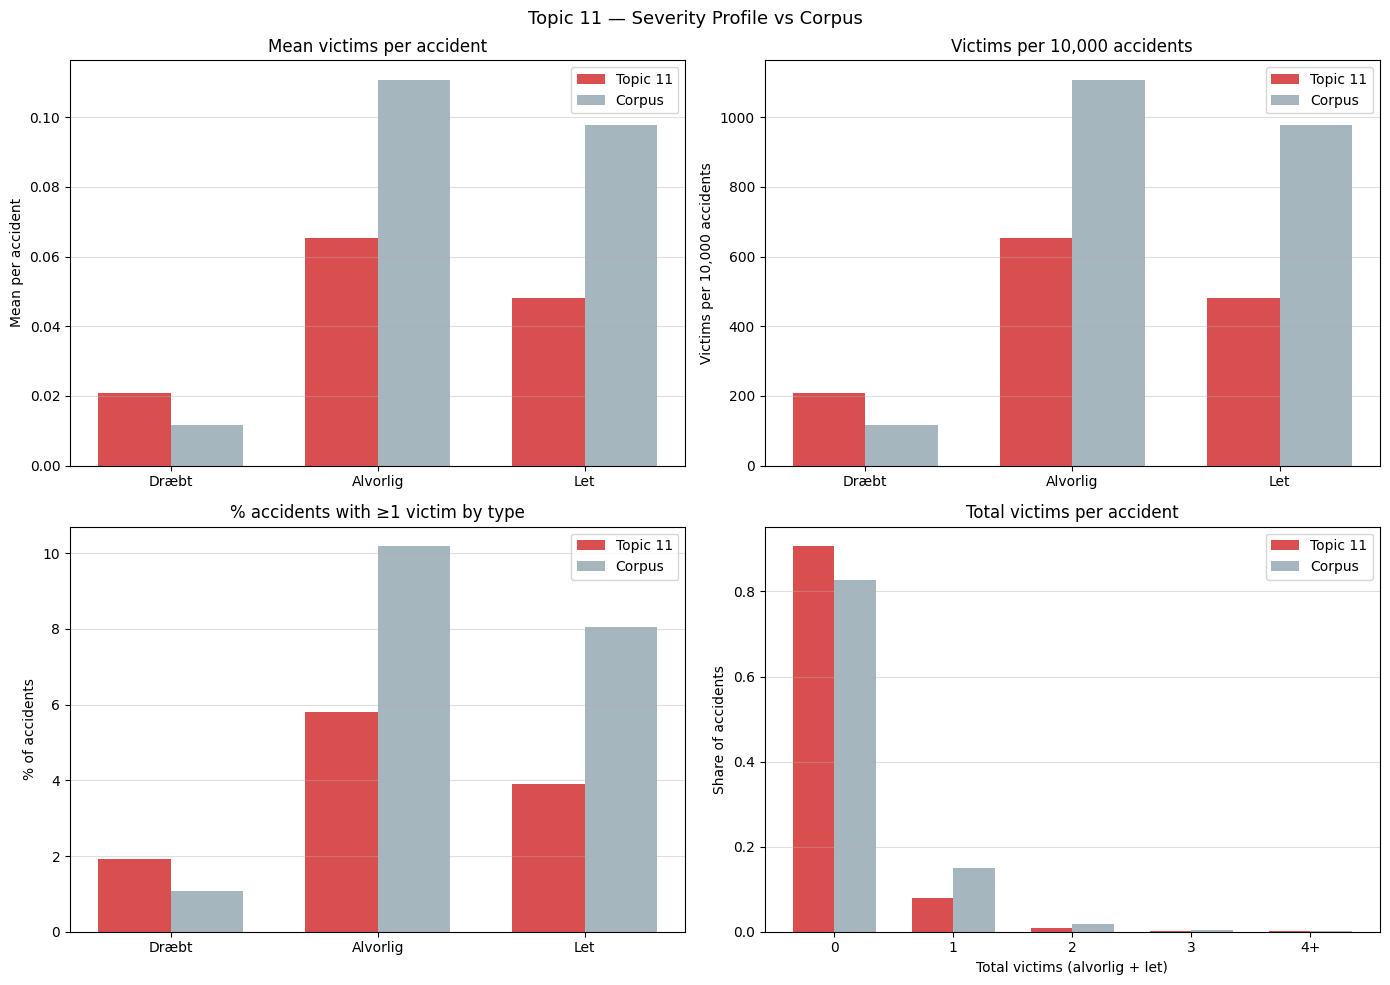

In [ ]:
# ── Topic 11 | 9. Severity anais — alvorlig, dræbt, let, total ────────────
from scipy import stats as sp_stats

alv_col = "ANTAL_ALV_TILSKADEKOMNE"
let_col = "ANTAL_LET_TILSKADEKOMNE"

draebte_col = next(
    (c for c in df_acc.columns if any(k in c.upper() for k in ["DRAEB", "DRÆBT"])),
    None
)
print(f"Columns  → alvorlig: {alv_col}, let: {let_col}, dræbt: {draebte_col}")
print(f"df_acc columns with 'ANT': {[c for c in df_acc.columns if 'ANT' in c.upper()]}")

t11    = df_acc[(df_acc["assigned_topic"] == 11) & (df_acc["year"] >= 2004)].copy()
others = df_acc[(df_acc["assigned_topic"] != 11) & (df_acc["year"] >= 2004)].copy()

for d in [t11, others]:
    d["ANTAL_TILSKADEKOMNE"] = d[alv_col].fillna(0) + d[let_col].fillna(0)

# ── Summary stats ──────────────────────────────────────────────────────────────
def sev_summary(sub, label):
    n = len(sub)
    print(f"\n── {label}  (n={n:,}) ──")
    print(f"  Mean alvorlig / accident : {sub[alv_col].fillna(0).mean():.4f}")
    print(f"  Mean let / accident      : {sub[let_col].fillna(0).mean():.4f}")
    print(f"  Mean total / accident    : {sub['ANTAL_TILSKADEKOMNE'].mean():.4f}")
    print(f"  ≥1 alvorlig (%)          : {(sub[alv_col].fillna(0) > 0).mean()*100:.2f}%")
    print(f"  ≥1 let (%)               : {(sub[let_col].fillna(0) > 0).mean()*100:.2f}%")
    if draebte_col:
        print(f"  Mean dræbt / accident    : {sub[draebte_col].fillna(0).mean():.4f}")
        print(f"  Dræbt per 10,000 acc.    : {sub[draebte_col].fillna(0).sum() / n * 10_000:.2f}")
        print(f"  ≥1 dræbt (%)             : {(sub[draebte_col].fillna(0) > 0).mean()*100:.2f}%")

sev_summary(t11,    "Topic 11 (Active Hit-and-Run)")
sev_summary(others, "Corpus (all other topics)")

# ── Statistical tests ─────────────────────────────────────────────────────────
# Primary test: fatalities (dræbt) — chi-square on any-fatality contingency table
if draebte_col:
    ct = np.array([
        [(t11[draebte_col].fillna(0) > 0).sum(),    (t11[draebte_col].fillna(0) == 0).sum()],
        [(others[draebte_col].fillna(0) > 0).sum(), (others[draebte_col].fillna(0) == 0).sum()],
    ])
    chi2, p_chi, _, _ = sp_stats.chi2_contingency(ct)
    print(f"\nChi-square (any dræbt): chi2={chi2:.3f}, p={p_chi:.4f}")
    print("→ " + ("Significant (p < 0.05)" if p_chi < 0.05 else "NOT significant (p ≥ 0.05)"))

    # Rate ratio with 95% CI (Poisson approximation)
    n11, n_oth = len(t11), len(others)
    r11  = t11[draebte_col].fillna(0).sum()
    r_oth = others[draebte_col].fillna(0).sum()
    rate11  = r11  / n11
    rate_oth = r_oth / n_oth
    rr = rate11 / rate_oth if rate_oth > 0 else np.nan
    se_log_rr = np.sqrt(1/r11 + 1/r_oth) if (r11 > 0 and r_oth > 0) else np.nan
    ci_lo = np.exp(np.log(rr) - 1.96 * se_log_rr) if not np.isnan(se_log_rr) else np.nan
    ci_hi = np.exp(np.log(rr) + 1.96 * se_log_rr) if not np.isnan(se_log_rr) else np.nan
    print(f"\nFatality rate ratio (Topic 11 / Corpus): {rr:.3f}  95% CI [{ci_lo:.3f}, {ci_hi:.3f}]")
    print(f"  Topic 11 : {rate11*10_000:.2f} dræbt per 10,000 accidents")
    print(f"  Corpus   : {rate_oth*10_000:.2f} dræbt per 10,000 accidents")

# Secondary: total tilskadekomne distribution
u, p_mw = sp_stats.mannwhitneyu(
    t11["ANTAL_TILSKADEKOMNE"].fillna(0),
    others["ANTAL_TILSKADEKOMNE"].fillna(0),
    alternative="two-sided"
)
print(f"\nMann-Whitney U (total tilskadekomne): U={u:.0f}, p={p_mw:.4f}")

# ── Plots ──────────────────────────────────────────────────────────────────────
sev_cols_plot = ([draebte_col] if draebte_col else []) + [alv_col, let_col]
xlabels = {
    draebte_col: "Dræbt",
    alv_col:     "Alvorlig",
    let_col:     "Let",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Topic 11 — Severity Profile vs Corpus", fontsize=13)
axes = axes.flatten()

xl = [xlabels[c] for c in sev_cols_plot]
x  = np.arange(len(sev_cols_plot))
w  = 0.35

# ① Mean per accident
means_t11    = [t11[c].fillna(0).mean()    for c in sev_cols_plot]
means_others = [others[c].fillna(0).mean() for c in sev_cols_plot]
axes[0].bar(x - w/2, means_t11,    w, label="Topic 11", color="#D32F2F", alpha=0.85)
axes[0].bar(x + w/2, means_others, w, label="Corpus",   color="#90A4AE", alpha=0.80)
axes[0].set_xticks(x); axes[0].set_xticklabels(xl)
axes[0].set_ylabel("Mean per accident")
axes[0].set_title("Mean victims per accident")
axes[0].legend(); axes[0].grid(axis="y", alpha=0.4)

# ② Rate per 10,000 accidents
n11, n_oth = len(t11), len(others)
rate_t11    = [t11[c].fillna(0).sum()    / n11  * 10_000 for c in sev_cols_plot]
rate_others = [others[c].fillna(0).sum() / n_oth * 10_000 for c in sev_cols_plot]
axes[1].bar(x - w/2, rate_t11,    w, label="Topic 11", color="#D32F2F", alpha=0.85)
axes[1].bar(x + w/2, rate_others, w, label="Corpus",   color="#90A4AE", alpha=0.80)
axes[1].set_xticks(x); axes[1].set_xticklabels(xl)
axes[1].set_ylabel("Victims per 10,000 accidents")
axes[1].set_title("Victims per 10,000 accidents")
axes[1].legend(); axes[1].grid(axis="y", alpha=0.4)

# ③ % accidents with ≥1 victim of each type
pct_t11    = [(t11[c].fillna(0) > 0).mean()*100    for c in sev_cols_plot]
pct_others = [(others[c].fillna(0) > 0).mean()*100 for c in sev_cols_plot]
axes[2].bar(x - w/2, pct_t11,    w, label="Topic 11", color="#D32F2F", alpha=0.85)
axes[2].bar(x + w/2, pct_others, w, label="Corpus",   color="#90A4AE", alpha=0.80)
axes[2].set_xticks(x); axes[2].set_xticklabels(xl)
axes[2].set_ylabel("% of accidents")
axes[2].set_title("% accidents with ≥1 victim by type")
axes[2].legend(); axes[2].grid(axis="y", alpha=0.4)

# ④ Distribution of total tilskadekomne (0–4+)
def victim_dist(s):
    return (s.fillna(0).astype(int).clip(upper=4)
             .value_counts(normalize=True)
             .reindex([0, 1, 2, 3, 4], fill_value=0))

t11_dist    = victim_dist(t11["ANTAL_TILSKADEKOMNE"])
others_dist = victim_dist(others["ANTAL_TILSKADEKOMNE"])
x3 = np.arange(5)
axes[3].bar(x3 - w/2, t11_dist.values,    w, label="Topic 11", color="#D32F2F", alpha=0.85)
axes[3].bar(x3 + w/2, others_dist.values, w, label="Corpus",   color="#90A4AE", alpha=0.80)
axes[3].set_xticks(x3); axes[3].set_xticklabels(["0", "1", "2", "3", "4+"])
axes[3].set_xlabel("Total victims (alvorlig + let)")
axes[3].set_ylabel("Share of accidents")
axes[3].set_title("Total victims per accident")
axes[3].legend(); axes[3].grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("results/topic11/severity_profile.png", dpi=150)
plt.show()


── Topic 11 (Hit-and-Run)  (n=5,525) ──
  Fatality (dr)       : 1.19%
  Serious (alv)       : 4.24%
  Dr or Alv           : 5.32%
  Dr per 10,000       : 119.46
  Alv per 10,000      : 423.53

── Corpus (all other topics)  (n=507,282) ──
  Fatality (dr)       : 1.21%
  Serious (alv)       : 11.21%
  Dr or Alv           : 12.18%
  Dr per 10,000       : 120.70
  Alv per 10,000      : 1120.88

Chi-square (dræbt): chi2=0.000, p=0.9822
Rate ratio: 0.990  95% CI [0.777, 1.261]
  Topic 11 : 119.46 per 10,000 accidents
  Corpus   : 120.70 per 10,000 accidents

Chi-square (alvorlig): chi2=267.923, p=0.0000
Rate ratio: 0.378  95% CI [0.332, 0.430]
  Topic 11 : 423.53 per 10,000 accidents
  Corpus   : 1120.88 per 10,000 accidents

Chi-square (dr or alv): chi2=240.756, p=0.0000
Rate ratio: 0.437  95% CI [0.390, 0.490]
  Topic 11 : 532.13 per 10,000 accidents
  Corpus   : 1217.57 per 10,000 accidents


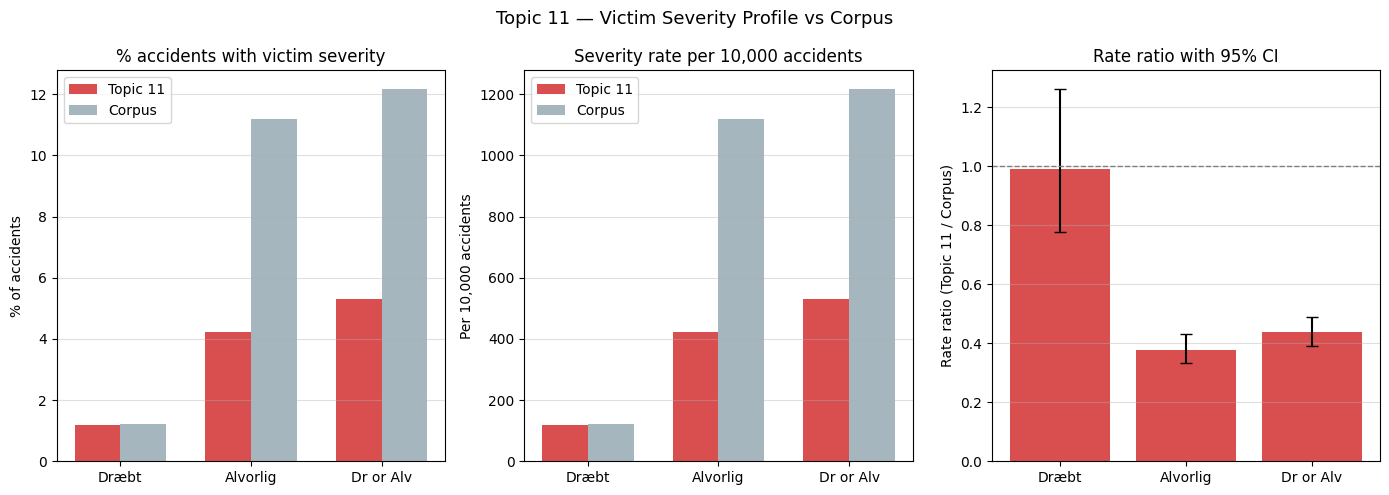

In [111]:
from scipy import stats as sp_stats

t11    = df_acc[(df_acc["assigned_topic"] == 11) & (df_acc["year"] >= 2000)].copy()
others = df_acc[(df_acc["assigned_topic"] != 11) & (df_acc["year"] >= 2000)].copy()

# topic 11: victim = element 2 or 3+ (element 1 is the fleeing driver)
t11["victim_dr"]      = ((t11["element_2_dr"] == 1) | (t11["element_3plus_dr"] == 1)).astype(int)
t11["victim_alv"]     = ((t11["element_2_alv"] == 1) | (t11["element_3plus_alv"] == 1)).astype(int)
t11["victim_dr_alv"]  = ((t11["victim_dr"] == 1) | (t11["victim_alv"] == 1)).astype(int)

# corpus: any element can be a victim
others["victim_dr"]      = ((others["element_1_dr"] == 1) | (others["element_2_dr"] == 1) | (others["element_3plus_dr"] == 1)).astype(int)
others["victim_alv"]     = ((others["element_1_alv"] == 1) | (others["element_2_alv"] == 1) | (others["element_3plus_alv"] == 1)).astype(int)
others["victim_dr_alv"]  = ((others["victim_dr"] == 1) | (others["victim_alv"] == 1)).astype(int)


cols    = ["victim_dr", "victim_alv", "victim_dr_alv"]
xlabels = ["Dræbt", "Alvorlig", "Dr or Alv"]

# ── Summary stats ──────────────────────────────────────────────────────────────
def sev_summary(sub, label):
    n = len(sub)
    print(f"\n── {label}  (n={n:,}) ──")
    print(f"  Fatality (dr)       : {sub['victim_dr'].mean()*100:.2f}%")
    print(f"  Serious (alv)       : {sub['victim_alv'].mean()*100:.2f}%")
    print(f"  Dr or Alv           : {sub['victim_dr_alv'].mean()*100:.2f}%")
    print(f"  Dr per 10,000       : {sub['victim_dr'].sum() / n * 10_000:.2f}")
    print(f"  Alv per 10,000      : {sub['victim_alv'].sum() / n * 10_000:.2f}")

sev_summary(t11,    "Topic 11 (Hit-and-Run)")
sev_summary(others, "Corpus (all other topics)")

# ── Statistical tests ──────────────────────────────────────────────────────────
for col, label in [("victim_dr", "dræbt"), ("victim_alv", "alvorlig"), ("victim_dr_alv", "dr or alv")]:
    ct = np.array([
        [t11[col].sum(),    len(t11)    - t11[col].sum()],
        [others[col].sum(), len(others) - others[col].sum()],
    ])
    chi2, p_chi, _, _ = sp_stats.chi2_contingency(ct)

    r11   = t11[col].sum()
    r_oth = others[col].sum()
    rate11   = r11  / len(t11)
    rate_oth = r_oth / len(others)
    rr = rate11 / rate_oth if rate_oth > 0 else np.nan
    se_log_rr = np.sqrt(1/r11 + 1/r_oth) if (r11 > 0 and r_oth > 0) else np.nan
    ci_lo = np.exp(np.log(rr) - 1.96 * se_log_rr)
    ci_hi = np.exp(np.log(rr) + 1.96 * se_log_rr)

    print(f"\nChi-square ({label}): chi2={chi2:.3f}, p={p_chi:.4f}")
    print(f"Rate ratio: {rr:.3f}  95% CI [{ci_lo:.3f}, {ci_hi:.3f}]")
    print(f"  Topic 11 : {rate11*10_000:.2f} per 10,000 accidents")
    print(f"  Corpus   : {rate_oth*10_000:.2f} per 10,000 accidents")

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Topic 11 — Victim Severity Profile vs Corpus", fontsize=13)

w = 0.35
x = np.arange(len(cols))

# ① % accidents with severity outcome
pct_t11    = [t11[c].mean()*100    for c in cols]
pct_others = [others[c].mean()*100 for c in cols]
axes[0].bar(x - w/2, pct_t11,    w, label="Topic 11", color="#D32F2F", alpha=0.85)
axes[0].bar(x + w/2, pct_others, w, label="Corpus",   color="#90A4AE", alpha=0.80)
axes[0].set_xticks(x); axes[0].set_xticklabels(xlabels)
axes[0].set_ylabel("% of accidents")
axes[0].set_title("% accidents with victim severity")
axes[0].legend(); axes[0].grid(axis="y", alpha=0.4)

# ② Rate per 10,000 accidents
rate_t11    = [t11[c].sum()    / len(t11)    * 10_000 for c in cols]
rate_others = [others[c].sum() / len(others) * 10_000 for c in cols]
axes[1].bar(x - w/2, rate_t11,    w, label="Topic 11", color="#D32F2F", alpha=0.85)
axes[1].bar(x + w/2, rate_others, w, label="Corpus",   color="#90A4AE", alpha=0.80)
axes[1].set_xticks(x); axes[1].set_xticklabels(xlabels)
axes[1].set_ylabel("Per 10,000 accidents")
axes[1].set_title("Severity rate per 10,000 accidents")
axes[1].legend(); axes[1].grid(axis="y", alpha=0.4)

# ③ Rate ratio with CI
rrs, ci_los, ci_his = [], [], []
for c in cols:
    r11   = t11[c].sum()
    r_oth = others[c].sum()
    rate11   = r11  / len(t11)
    rate_oth = r_oth / len(others)
    rr = rate11 / rate_oth if rate_oth > 0 else np.nan
    se = np.sqrt(1/r11 + 1/r_oth) if (r11 > 0 and r_oth > 0) else np.nan
    rrs.append(rr)
    ci_los.append(rr - np.exp(np.log(rr) - 1.96*se))
    ci_his.append(np.exp(np.log(rr) + 1.96*se) - rr)

axes[2].bar(x, rrs, color="#D32F2F", alpha=0.85)
axes[2].errorbar(x, rrs, yerr=[ci_los, ci_his], fmt="none", color="black", capsize=4)
axes[2].axhline(1, color="grey", linestyle="--", linewidth=1)
axes[2].set_xticks(x); axes[2].set_xticklabels(xlabels)
axes[2].set_ylabel("Rate ratio (Topic 11 / Corpus)")
axes[2].set_title("Rate ratio with 95% CI")
axes[2].grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("topic11_severity_victims.png", dpi=150, bbox_inches="tight")
plt.show()

In [39]:
t11 = df_acc[df_acc["assigned_topic"] == 11]
print(t11["age_group"].value_counts(dropna=False))
print(t11["age_group"].value_counts(normalize=True, dropna=False).mul(100).round(2))

age_group
46-60      1772
26-35      1542
36-45      1357
61+        1044
0-20        966
NaN         927
21-25       894
Unknown       5
Name: count, dtype: int64
age_group
46-60      20.83
26-35      18.13
36-45      15.95
61+        12.27
0-20       11.36
NaN        10.90
21-25      10.51
Unknown     0.06
Name: proportion, dtype: float64


In [41]:
t11 = df_acc[df_acc["assigned_topic"] == 11].copy()
t11_fatal = t11[t11[draebte_col].fillna(0) > 0]

corpus_fatal = df_acc[df_acc[draebte_col].fillna(0) > 0]

print(f"Topic 11 fatal: {len(t11_fatal):,}  |  Corpus fatal: {len(corpus_fatal):,}")

comparison = pd.concat([
    t11_fatal["age_group"].value_counts(normalize=True).rename("Topic 11 fatal"),
    corpus_fatal["age_group"].value_counts(normalize=True).rename("Corpus fatal"),
], axis=1).fillna(0).mul(100).round(2)

comparison["lift"] = (comparison["Topic 11 fatal"] / comparison["Corpus fatal"].replace(0, np.nan)).round(3)
comparison = comparison.sort_values("Topic 11 fatal", ascending=False)

print(comparison.to_string())

Topic 11 fatal: 217  |  Corpus fatal: 26,853
           Topic 11 fatal  Corpus fatal   lift
age_group                                     
46-60               26.73         18.67  1.432
61+                 24.88         20.84  1.194
36-45               19.82         16.42  1.207
26-35               19.35         19.03  1.017
21-25                6.45         12.21  0.528
0-20                 2.76         12.82  0.215
Unknown              0.00          0.01  0.000


In [23]:
# Filter to post-2000 and topic 11
t11 = df_acc[(df_acc["assigned_topic"] == 11) & (df_acc["year"] >= 2000)]
baseline = df_acc[df_acc["year"] >= 2000]

for col in ["element_1_age_group", "element_2_age_group"]:
    topic_share = t11[col].value_counts(normalize=True)
    baseline_share = baseline[col].value_counts(normalize=True)
    
    lift = (topic_share / baseline_share).dropna().sort_values(ascending=False)
    
    print(f"\n{col}")
    print(f"{'Age group':<15} {'Topic 11':>10} {'Baseline':>10} {'Lift':>8}")
    print("-" * 45)
    for age in lift.index:
        print(f"{str(age):<15} {topic_share.get(age, 0):>10.3f} {baseline_share.get(age, 0):>10.3f} {lift[age]:>8.3f}")


element_1_age_group
Age group         Topic 11   Baseline     Lift
---------------------------------------------
Unknown              0.001      0.000    3.578
21-25                0.134      0.126    1.062
26-35                0.211      0.199    1.057
0-20                 0.144      0.142    1.012
46-60                0.199      0.202    0.982
61+                  0.152      0.159    0.955
36-45                0.160      0.171    0.935

element_2_age_group
Age group         Topic 11   Baseline     Lift
---------------------------------------------
Unknown              0.000      0.000    2.166
46-60                0.251      0.237    1.058
21-25                0.110      0.105    1.055
26-35                0.198      0.192    1.031
36-45                0.189      0.185    1.025
0-20                 0.126      0.138    0.912
61+                  0.124      0.143    0.872


/tmp/ipykernel_2360576/2580935228.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  t11_filtered.groupby(["year", col])
/tmp/ipykernel_2360576/2580935228.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  t11_filtered.groupby(["year", col])
/tmp/ipykernel_2360576/2580935228.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  t11_filtered.groupby(["year", col])
/tmp/ipykernel_2360576/2580935228.py:17: FutureWarning:

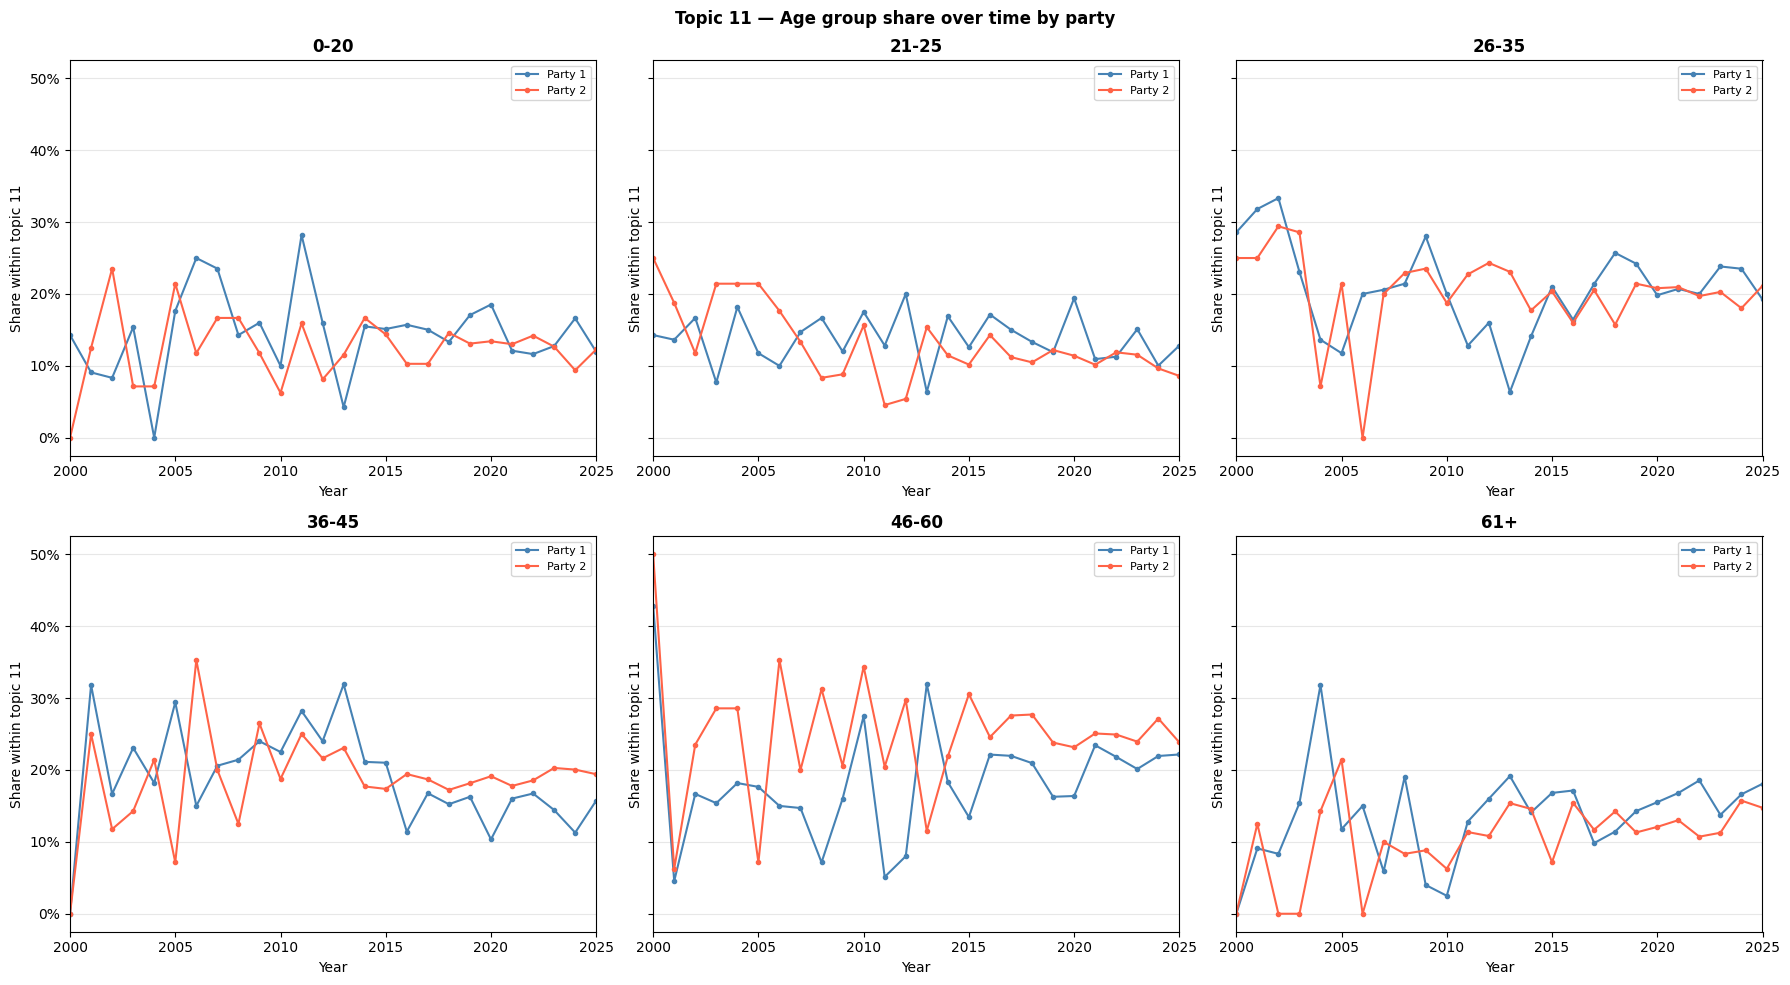

In [38]:
t11 = df_acc[(df_acc["assigned_topic"] == 11) & (df_acc["year"] >= 2000)]

age_groups = ['0-20', '21-25', '26-35', '36-45', '46-60', '61+']

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
axes = axes.flatten()

for ax, age_group in zip(axes, age_groups):
    for col, label, color in zip(
        ["element_1_age_group", "element_2_age_group"],
        ["Party 1", "Party 2"],
        ["steelblue", "tomato"]
    ):
        t11_filtered = t11[t11[col].notna() & (t11[col] != "Unknown")]
        
        yearly = (
            t11_filtered.groupby(["year", col])
            .size()
            .unstack(fill_value=0)
        )
        yearly_share = yearly.div(yearly.sum(axis=1), axis=0)
        
        if age_group in yearly_share.columns:
            ax.plot(yearly_share.index, yearly_share[age_group],
                    label=label, color=color, linewidth=1.5, marker="o", markersize=3)
    
    ax.set_title(age_group, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Share within topic 11")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.legend(fontsize=8)
    ax.set_xlim(2000, t11["AAR"].max())
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Topic 11 — Age group share over time by party", fontweight="bold")
plt.tight_layout()
plt.savefig("topic11_age_by_group.png", dpi=150, bbox_inches="tight")
plt.show()

In [63]:
t11 = df_acc[df_acc["assigned_topic"] == 11]

print("Topic 11 - element 2 or 3+ fatalities (Dr):")
print((t11[["element_2_dr", "element_3plus_dr"]].max(axis=1)).value_counts())
print(f"Share: {(t11[['element_2_dr', 'element_3plus_dr']].max(axis=1)).mean():.3f}")

print("\nTopic 11 - element 2 or 3+ serious injury (Alv):")
print((t11[["element_2_alv", "element_3plus_alv"]].max(axis=1)).value_counts())
print(f"Share: {(t11[['element_2_alv', 'element_3plus_alv']].max(axis=1)).mean():.3f}")

Topic 11 - element 2 or 3+ fatalities (Dr):
0    5506
1      66
Name: count, dtype: int64
Share: 0.012

Topic 11 - element 2 or 3+ serious injury (Alv):
0    5337
1     235
Name: count, dtype: int64
Share: 0.042


In [62]:
t11_severe = df_acc[
    (df_acc["assigned_topic"] == 11) & 
    (
        (df_acc["element_2_dr"] == 1) | 
        (df_acc["element_2_alv"] == 1) |
        (df_acc["element_3plus_dr"] == 1) | 
        (df_acc["element_3plus_alv"] == 1)
    )
]

print("Topic 11 - element 2 fatality or serious injury:")
print(f"Count: {len(t11_severe)}")
print(f"Share: {len(t11_severe) / len(t11):.3f}")

Topic 11 - element 2 fatality or serious injury:
Count: 295
Share: 0.053


In [34]:
fatal_acc = (
    (df_acc["element_1_dr"] == 1) |
    (df_acc["element_2_dr"] == 1) |
    (df_acc["element_3plus_dr"] == 1)
).astype(int)
t11_fatal_rate = fatal_acc[df_acc["assigned_topic"] == 11].mean()
corpus_fatal_rate = fatal_acc[df_acc["assigned_topic"] != 11].mean()
print(f"\nFatality rate (any element) - Topic 11: {t11_fatal_rate:.3%}")
print(f"Fatality rate (any element) - Corpus: {corpus_fatal_rate:.3%}")


Fatality rate (any element) - Topic 11: 1.902%
Fatality rate (any element) - Corpus: 1.630%


In [35]:
serious_acc = (
    (df_acc["element_1_alv"] == 1) |
    (df_acc["element_2_alv"] == 1) |
    (df_acc["element_3plus_alv"] == 1)
).astype(int)
t11_serious_rate = serious_acc[df_acc["assigned_topic"] == 11].mean()
corpus_serious_rate = serious_acc[df_acc["assigned_topic"] != 11].mean()
print(f"\nSerious injury rate (any element) - Topic 11: {t11_serious_rate:.3%}")
print(f"Serious injury rate (any element) - Corpus: {corpus_serious_rate:.3%}")


Serious injury rate (any element) - Topic 11: 5.815%
Serious injury rate (any element) - Corpus: 15.526%


In [36]:
from scipy.stats import chi2_contingency
import numpy as np

t11 = df_acc["assigned_topic"] == 11
corpus = ~t11

# Fatality
fatal = (
    (df_acc["element_1_dr"] == 1) |
    (df_acc["element_2_dr"] == 1) |
    (df_acc["element_3plus_dr"] == 1)
).astype(int)

t11_f = fatal[t11].sum()
t11_n = t11.sum()
corp_f = fatal[corpus].sum()
corp_n = corpus.sum()

table = np.array([[t11_f, t11_n - t11_f],
                  [corp_f, corp_n - corp_f]])
chi2, p, dof, _ = chi2_contingency(table)
rr = (t11_f / t11_n) / (corp_f / corp_n)
se = np.sqrt(1/t11_f - 1/t11_n + 1/corp_f - 1/corp_n)
ci_lo, ci_hi = np.exp(np.log(rr) - 1.96*se), np.exp(np.log(rr) + 1.96*se)
print(f"Fatality: chi2={chi2:.3f}, p={p:.4f}, RR={rr:.3f}, 95% CI [{ci_lo:.3f}, {ci_hi:.3f}]")

# Serious injury
serious = (
    (df_acc["element_1_alv"] == 1) |
    (df_acc["element_2_alv"] == 1) |
    (df_acc["element_3plus_alv"] == 1)
).astype(int)

t11_s = serious[t11].sum()
corp_s = serious[corpus].sum()

table2 = np.array([[t11_s, t11_n - t11_s],
                   [corp_s, corp_n - corp_s]])
chi2_s, p_s, _, _ = chi2_contingency(table2)
rr_s = (t11_s / t11_n) / (corp_s / corp_n)
se_s = np.sqrt(1/t11_s - 1/t11_n + 1/corp_s - 1/corp_n)
ci_lo_s, ci_hi_s = np.exp(np.log(rr_s) - 1.96*se_s), np.exp(np.log(rr_s) + 1.96*se_s)
print(f"Serious:  chi2={chi2_s:.3f}, p={p_s:.4f}, RR={rr_s:.3f}, 95% CI [{ci_lo_s:.3f}, {ci_hi_s:.3f}]")

Fatality: chi2=2.392, p=0.1219, RR=1.167, 95% CI [0.966, 1.410]
Serious:  chi2=398.665, p=0.0000, RR=0.375, 95% CI [0.337, 0.416]


In [37]:
df_acc.head()

,accident_date,report_category,encoded_accident_situation,accident_situation,police_narrative,year,accident_id,main_situation_class,n_words,topic_main_0_3,...,UHELDKOMMUNE,AAR,sprit_flag,has_cyclist,max_element_number,KODE_UHELDKOMMUNE,x,y,kommune_group,assigned_topic
0,1985-01-01,Anmsuh,242,Mødeuheld i øvrigt,part 1 overskrider spæreflade og påkører modkø...,1985,80001,2,9,0,...,København,1985.0,1,0,2.0,101,12.610763,55.654171,Hovedstad,0
1,1985-01-01,Anmsuh,710,P. køretøj i h. vejside,1 der ukendt påkører den parkerede 2. 1 formen...,1985,80002,7,11,3,...,København,1985.0,0,0,NaN,101,12.610763,55.654171,Hovedstad,3
2,1985-01-01,Pskduh,11,Ligeudkørsel til h.vejside,part 1 mister herredømmet over bilen og påkøre...,1985,80003,0,12,-1,...,København,1985.0,0,0,1.0,101,12.568792,55.675252,Hovedstad,-1
3,1985-01-01,Pskduh,811,Fodg. fra h. fortov,part 2 træder pludselig ud på kørebanen og påk...,1985,80004,8,12,0,...,København,1985.0,1,0,2.0,101,12.548995,55.694239,Hovedstad,0
4,1985-01-01,Pskduh,241,Mødeuh. i el. 2.s kørebane,part 1 mister grundet glat føre herredømmet ov...,1985,80005,2,19,0,...,København,1985.0,1,0,3.0,101,12.539729,55.689313,Hovedstad,0


In [ ]:
print("Element 2 age group - fatality or serious injury (e2 or e3+) in topic 11:")
print(t11_severe["element_2_age_group"].value_counts(normalize=True).round(3))

Element 2 age group - fatality or serious injury (e2 or e3+) in topic 11:
element_2_age_group
46-60      0.265
61+        0.216
0-20       0.158
36-45      0.141
26-35      0.120
21-25      0.100
Unknown    0.000
Name: proportion, dtype: float64


In [61]:
print("Element 1 age group when element 2 is fatality or serious injured - topic 11:")
print(t11_severe["element_1_age_group"].value_counts(normalize=True).round(3))

Element 1 age group when element 2 is fatality or serious injured - topic 11:
element_1_age_group
26-35      0.238
46-60      0.189
36-45      0.184
61+        0.178
0-20       0.119
21-25      0.092
Unknown    0.000
Name: proportion, dtype: float64


In [30]:
t11 = df_acc[(df_acc["assigned_topic"] == 11) & (df_acc["year"] >= 2000)].copy()


In [34]:
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests
t11 = df_acc[(df_acc["assigned_topic"] == 11) & (df_acc["year"] >= 2000)].copy()

t11_filtered = t11[t11["element_1_age_group"].notna() & (t11["element_1_age_group"] != "Unknown")]
baseline_filtered = df_acc[df_acc["element_1_age_group"].notna() & (df_acc["element_1_age_group"] != "Unknown") & (df_acc["year"] >= 2000)]

t11_counts = t11_filtered["element_1_age_group"].value_counts()
rest_counts = df_acc[
    (df_acc["assigned_topic"] != 11) & 
    df_acc["element_1_age_group"].notna() & 
    (df_acc["element_1_age_group"] != "Unknown") &
    (df_acc["year"] >= 2000)
]["element_1_age_group"].value_counts()

topic_share = t11_filtered["element_1_age_group"].value_counts(normalize=True)
baseline_share = baseline_filtered["element_1_age_group"].value_counts(normalize=True)

categories = t11_counts.index.union(rest_counts.index)

pvalues = []
labels = []

for cat in categories:
    a = t11_counts.get(cat, 0)
    b = len(t11_filtered) - a
    c = rest_counts.get(cat, 0)
    d = len(baseline_filtered) - len(t11_filtered) - c
    
    if a == 0 or c == 0:
        continue
    
    _, p, _, _ = chi2_contingency([[a, b], [c, d]])
    pvalues.append(p)
    labels.append(cat)


reject, pvals_corrected, _, _ = multipletests(pvalues, method="bonferroni")

print(f"{'Age group':<15} {'Topic 11':>10} {'Baseline':>10} {'Lift':>8} {'p (raw)':>12} {'p (corrected)':>15} {'Significant':>12}")
print("-" * 85)
for label, p_raw, p_corr, sig in zip(labels, pvalues, pvals_corrected, reject):
    t_share = topic_share.get(label, 0)
    b_share = baseline_share.get(label, 0)
    lift = t_share / b_share if b_share > 0 else float("nan")
    print(f"{str(label):<15} {t_share:>10.3f} {b_share:>10.3f} {lift:>8.3f} {p_raw:>12.4f} {p_corr:>15.4f} {str(sig):>12}")

Age group         Topic 11   Baseline     Lift      p (raw)   p (corrected)  Significant
-------------------------------------------------------------------------------------
0-20                 0.144      0.142    1.013       0.7962          1.0000        False
21-25                0.134      0.126    1.063       0.1909          1.0000        False
26-35                0.211      0.199    1.058       0.1107          0.6645        False
36-45                0.160      0.171    0.936       0.1097          0.6583        False
46-60                0.199      0.202    0.983       0.6596          1.0000        False
61+                  0.152      0.159    0.956       0.2958          1.0000        False


In [33]:
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests

t11_filtered = t11[t11["element_2_age_group"].notna() & (t11["element_2_age_group"] != "Unknown")]
baseline_filtered = df_acc[df_acc["element_2_age_group"].notna() & (df_acc["element_2_age_group"] != "Unknown")]

t11_counts = t11_filtered["element_2_age_group"].value_counts()
rest_counts = df_acc[
    (df_acc["assigned_topic"] != 11) & 
    df_acc["element_2_age_group"].notna() & 
    (df_acc["element_2_age_group"] != "Unknown") &
    (df_acc["year"] >= 2000)
]["element_2_age_group"].value_counts()

topic_share = t11_filtered["element_2_age_group"].value_counts(normalize=True)
baseline_share = baseline_filtered["element_2_age_group"].value_counts(normalize=True)

categories = t11_counts.index.union(rest_counts.index)

pvalues = []
labels = []

for cat in categories:
    a = t11_counts.get(cat, 0)
    b = len(t11_filtered) - a
    c = rest_counts.get(cat, 0)
    d = len(baseline_filtered) - len(t11_filtered) - c
    
    if a == 0 or c == 0:
        continue
    
    _, p, _, _ = chi2_contingency([[a, b], [c, d]])
    pvalues.append(p)
    labels.append(cat)


reject, pvals_corrected, _, _ = multipletests(pvalues, method="bonferroni")

print(f"{'Age group':<15} {'Topic 11':>10} {'Baseline':>10} {'Lift':>8} {'p (raw)':>12} {'p (corrected)':>15} {'Significant':>12}")
print("-" * 85)
for label, p_raw, p_corr, sig in zip(labels, pvalues, pvals_corrected, reject):
    t_share = topic_share.get(label, 0)
    b_share = baseline_share.get(label, 0)
    lift = t_share / b_share if b_share > 0 else float("nan")
    print(f"{str(label):<15} {t_share:>10.3f} {b_share:>10.3f} {lift:>8.3f} {p_raw:>12.4f} {p_corr:>15.4f} {str(sig):>12}")

Age group         Topic 11   Baseline     Lift      p (raw)   p (corrected)  Significant
-------------------------------------------------------------------------------------
0-20                 0.126      0.148    0.852       0.0000          0.0000         True
21-25                0.111      0.122    0.904       0.0000          0.0000         True
26-35                0.198      0.208    0.951       0.0000          0.0000         True
36-45                0.190      0.182    1.042       0.0000          0.0000         True
46-60                0.251      0.210    1.194       0.0000          0.0000         True
61+                  0.124      0.129    0.963       0.0000          0.0000         True


In [1]:
from scipy.stats import chi2_contingency

topic_share = t11["LYS"].value_counts(normalize=True)
baseline_share = df_acc["LYS"].value_counts(normalize=True)

# contingency table: topic 11 counts vs rest of dataset
t11_counts = t11["LYS"].value_counts()
rest_counts = df_acc[df_acc["assigned_topic"] != 11]["LYS"].value_counts()

contingency = pd.DataFrame({"topic_11": t11_counts, "rest": rest_counts}).fillna(0)
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square test for LYS distribution:")
print(f"chi2 = {chi2:.3f}, dof = {dof}, p = {p:.4f}")


NameError: name 't11' is not defined

In [81]:
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests

t11_filtered = t11[t11["element_1_age_group"].notna() & (t11["element_1_age_group"] != "Unknown")]
baseline_filtered = df_acc[df_acc["element_1_age_group"].notna() & (df_acc["element_1_age_group"] != "Unknown")]

t11_counts = t11_filtered["kommune_group"].value_counts()
rest_counts = df_acc[
    (df_acc["assigned_topic"] != 11) &
    df_acc["element_1_age_group"].notna() &
    (df_acc["element_1_age_group"] != "Unknown")
]["kommune_group"].value_counts()

topic_share = t11_filtered["kommune_group"].value_counts(normalize=True)
baseline_share = baseline_filtered["kommune_group"].value_counts(normalize=True)

categories = t11_counts.index.union(rest_counts.index)

pvalues = []
labels = []

for cat in categories:
    a = t11_counts.get(cat, 0)
    b = len(t11_filtered) - a
    c = rest_counts.get(cat, 0)
    d = len(baseline_filtered) - len(t11_filtered) - c

    if a == 0 or c == 0:
        continue

    _, p, _, _ = chi2_contingency([[a, b], [c, d]])
    pvalues.append(p)
    labels.append(cat)

reject, pvals_corrected, _, _ = multipletests(pvalues, method="bonferroni")

print(f"{'Kommune group':<20} {'Topic 11':>10} {'Baseline':>10} {'Lift':>8} {'p (raw)':>12} {'p (corrected)':>15} {'Significant':>12}")
print("-" * 90)
for label, p_raw, p_corr, sig in zip(labels, pvalues, pvals_corrected, reject):
    t_share = topic_share.get(label, 0)
    b_share = baseline_share.get(label, 0)
    lift = t_share / b_share if b_share > 0 else float("nan")
    print(f"{str(label):<20} {t_share:>10.3f} {b_share:>10.3f} {lift:>8.3f} {p_raw:>12.4f} {p_corr:>15.4f} {str(sig):>12}")

Kommune group          Topic 11   Baseline     Lift      p (raw)   p (corrected)  Significant
------------------------------------------------------------------------------------------
Hovedstad                 0.400      0.283    1.415       0.0000          0.0000         True
Provinsby                 0.213      0.234    0.910       0.0084          0.0420         True
Land                      0.129      0.220    0.587       0.0000          0.0000         True
Opland                    0.129      0.150    0.861       0.0017          0.0084         True
Storby                    0.129      0.113    1.135       0.0065          0.0323         True


In [82]:
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests

age_groups = ['0-20', '21-25', '26-35', '36-45', '46-60', '61+']

for age_group in age_groups:
    t11_filtered = t11[
        (t11["element_1_age_group"] == age_group)
    ]
    baseline_filtered = df_acc[
        (df_acc["element_1_age_group"] == age_group)
    ]

    t11_counts = t11_filtered["kommune_group"].value_counts()
    rest_counts = df_acc[
        (df_acc["assigned_topic"] != 11) &
        (df_acc["element_1_age_group"] == age_group)
    ]["kommune_group"].value_counts()

    topic_share = t11_filtered["kommune_group"].value_counts(normalize=True)
    baseline_share = baseline_filtered["kommune_group"].value_counts(normalize=True)

    categories = t11_counts.index.union(rest_counts.index)

    pvalues = []
    labels = []

    for cat in categories:
        a = t11_counts.get(cat, 0)
        b = len(t11_filtered) - a
        c = rest_counts.get(cat, 0)
        d = len(baseline_filtered) - len(t11_filtered) - c

        if a == 0 or c == 0:
            continue

        _, p, _, _ = chi2_contingency([[a, b], [c, d]])
        pvalues.append(p)
        labels.append(cat)

    if not pvalues:
        print(f"\nAge group {age_group}: insufficient data")
        continue

    reject, pvals_corrected, _, _ = multipletests(pvalues, method="bonferroni")

    print(f"\n{'='*90}")
    print(f"Age group: {age_group} (n topic 11 = {len(t11_filtered)}, n baseline = {len(baseline_filtered)})")
    print(f"{'='*90}")
    print(f"{'Kommune group':<20} {'Topic 11':>10} {'Baseline':>10} {'Lift':>8} {'p (raw)':>12} {'p (corrected)':>15} {'Significant':>12}")
    print("-" * 90)
    for label, p_raw, p_corr, sig in zip(labels, pvalues, pvals_corrected, reject):
        t_share = topic_share.get(label, 0)
        b_share = baseline_share.get(label, 0)
        lift = t_share / b_share if b_share > 0 else float("nan")
        print(f"{str(label):<20} {t_share:>10.3f} {b_share:>10.3f} {lift:>8.3f} {p_raw:>12.4f} {p_corr:>15.4f} {str(sig):>12}")


Age group: 0-20 (n topic 11 = 441, n baseline = 114602)
Kommune group          Topic 11   Baseline     Lift      p (raw)   p (corrected)  Significant
------------------------------------------------------------------------------------------
Hovedstad                 0.393      0.213    1.843       0.0000          0.0000         True
Land                      0.132      0.262    0.503       0.0000          0.0000         True
Opland                    0.109      0.163    0.669       0.0030          0.0149         True
Provinsby                 0.227      0.253    0.897       0.2434          1.0000        False
Storby                    0.139      0.108    1.282       0.0438          0.2188        False

Age group: 21-25 (n topic 11 = 412, n baseline = 104848)
Kommune group          Topic 11   Baseline     Lift      p (raw)   p (corrected)  Significant
------------------------------------------------------------------------------------------
Hovedstad                 0.417      0.293   

In [73]:
from scipy.stats import chi2_contingency

topic_share = t11["LYS"].value_counts(normalize=True)
baseline_share = df_acc["LYS"].value_counts(normalize=True)

# contingency table: topic 11 counts vs rest of dataset
t11_counts = t11["LYS"].value_counts()
rest_counts = df_acc[df_acc["assigned_topic"] != 11]["LYS"].value_counts()

contingency = pd.DataFrame({"topic_11": t11_counts, "rest": rest_counts}).fillna(0)
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square test for LYS distribution:")
print(f"chi2 = {chi2:.3f}, dof = {dof}, p = {p:.4f}")


Chi-square test for LYS distribution:
chi2 = 2041.711, dof = 3, p = 0.0000


In [77]:
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests

t11_counts = t11["LYS"].value_counts()
rest_counts = df_acc[df_acc["assigned_topic"] != 11]["LYS"].value_counts()

topic_share = t11["LYS"].value_counts(normalize=True)
baseline_share = df_acc["LYS"].value_counts(normalize=True)

categories = t11_counts.index.union(rest_counts.index)

pvalues = []
labels = []

for cat in categories:
    a = t11_counts.get(cat, 0)
    b = len(t11) - a
    c = rest_counts.get(cat, 0)
    d = len(df_acc) - len(t11) - c
    
    _, p, _, _ = chi2_contingency([[a, b], [c, d]])
    pvalues.append(p)
    labels.append(cat)

reject, pvals_corrected, _, _ = multipletests(pvalues, method="bonferroni")

print(f"{'LYS':<15} {'Topic 11':>10} {'Baseline':>10} {'Lift':>8} {'p (raw)':>12} {'p (corrected)':>15} {'Significant':>12}")
print("-" * 85)
for label, p_raw, p_corr, sig in zip(labels, pvalues, pvals_corrected, reject):
    t_share = topic_share.get(label, 0)
    b_share = baseline_share.get(label, 0)
    lift = t_share / b_share if b_share > 0 else float("nan")
    print(f"{str(label):<15} {t_share:>10.3f} {b_share:>10.3f} {lift:>8.3f} {p_raw:>12.4f} {p_corr:>15.4f} {str(sig):>12}")

LYS               Topic 11   Baseline     Lift      p (raw)   p (corrected)  Significant
-------------------------------------------------------------------------------------
Dagsl                0.619      0.657    0.942       0.0000          0.0000         True
Mørke                0.284      0.292    0.971       0.2856          1.0000        False
Tusmk                0.030      0.041    0.736       0.0001          0.0003         True
Uopl                 0.067      0.009    7.236       0.0000          0.0000         True


In [76]:
from scipy.stats import chi2_contingency

topic_share = t11["VEJRFORHOLD"].value_counts(normalize=True)
baseline_share = df_acc["VEJRFORHOLD"].value_counts(normalize=True)

# contingency table: topic 11 counts vs rest of dataset
t11_counts = t11["VEJRFORHOLD"].value_counts()
rest_counts = df_acc[df_acc["assigned_topic"] != 11]["VEJRFORHOLD"].value_counts()

contingency = pd.DataFrame({"topic_11": t11_counts, "rest": rest_counts}).fillna(0)
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square test for VEJR distribution:")
print(f"chi2 = {chi2:.3f}, dof = {dof}, p = {p:.4f}")


Chi-square test for VEJR distribution:
chi2 = 1128.512, dof = 10, p = 0.0000


In [75]:
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests

t11_counts = t11["VEJRFORHOLD"].value_counts()
rest_counts = df_acc[df_acc["assigned_topic"] != 11]["VEJRFORHOLD"].value_counts()

topic_share = t11["VEJRFORHOLD"].value_counts(normalize=True)
baseline_share = df_acc["VEJRFORHOLD"].value_counts(normalize=True)

categories = t11_counts.index.union(rest_counts.index)

pvalues = []
labels = []

for cat in categories:
    a = t11_counts.get(cat, 0)
    b = len(t11) - a
    c = rest_counts.get(cat, 0)
    d = len(df_acc) - len(t11) - c
    
    _, p, _, _ = chi2_contingency([[a, b], [c, d]])
    pvalues.append(p)
    labels.append(cat)

reject, pvals_corrected, _, _ = multipletests(pvalues, method="bonferroni")

print(f"{'VEJRFORHOLD':<15} {'Topic 11':>10} {'Baseline':>10} {'Lift':>8} {'p (raw)':>12} {'p (corrected)':>15} {'Significant':>12}")
print("-" * 85)
for label, p_raw, p_corr, sig in zip(labels, pvalues, pvals_corrected, reject):
    t_share = topic_share.get(label, 0)
    b_share = baseline_share.get(label, 0)
    lift = t_share / b_share if b_share > 0 else float("nan")
    print(f"{str(label):<15} {t_share:>10.3f} {b_share:>10.3f} {lift:>8.3f} {p_raw:>12.4f} {p_corr:>15.4f} {str(sig):>12}")

VEJRFORHOLD       Topic 11   Baseline     Lift      p (raw)   p (corrected)  Significant
-------------------------------------------------------------------------------------
Blæst                0.001      0.002    0.297       0.0151          0.1663        False
Regn                 0.092      0.120    0.773       0.0000          0.0000         True
Regn/blæst           0.003      0.003    1.048       0.8952          1.0000        False
Regn/tåge            0.002      0.002    1.191       0.6048          1.0000        False
Sne                  0.009      0.020    0.455       0.0000          0.0000         True
Sne/blæst            0.001      0.002    0.707       0.4599          1.0000        False
Tåge                 0.003      0.010    0.294       0.0000          0.0000         True
Tåge/blæst           0.000      0.000    0.000       1.0000          1.0000        False
Tåge/sne             0.001      0.001    0.802       0.8436          1.0000        False
Tørt                 0.8

In [84]:
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests

t11_counts = t11["VEJKATEGORI"].value_counts()
rest_counts = df_acc[df_acc["assigned_topic"] != 11]["VEJKATEGORI"].value_counts()

topic_share = t11["VEJKATEGORI"].value_counts(normalize=True)
baseline_share = df_acc["VEJKATEGORI"].value_counts(normalize=True)

categories = t11_counts.index.union(rest_counts.index)

pvalues = []
labels = []

for cat in categories:
    a = t11_counts.get(cat, 0)
    b = len(t11) - a
    c = rest_counts.get(cat, 0)
    d = len(df_acc) - len(t11) - c
    
    _, p, _, _ = chi2_contingency([[a, b], [c, d]])
    pvalues.append(p)
    labels.append(cat)

reject, pvals_corrected, _, _ = multipletests(pvalues, method="bonferroni")

print(f"{'VEJKATEGORI':<15} {'Topic 11':>10} {'Baseline':>10} {'Lift':>8} {'p (raw)':>12} {'p (corrected)':>15} {'Significant':>12}")
print("-" * 85)
for label, p_raw, p_corr, sig in zip(labels, pvalues, pvals_corrected, reject):
    t_share = topic_share.get(label, 0)
    b_share = baseline_share.get(label, 0)
    lift = t_share / b_share if b_share > 0 else float("nan")
    print(f"{str(label):<15} {t_share:>10.3f} {b_share:>10.3f} {lift:>8.3f} {p_raw:>12.4f} {p_corr:>15.4f} {str(sig):>12}")

VEJKATEGORI       Topic 11   Baseline     Lift      p (raw)   p (corrected)  Significant
-------------------------------------------------------------------------------------
Komv                 0.754      0.785    0.960       0.0000          0.0000         True
Hldv                 0.193      0.200    0.965       0.1893          0.7571        False
Fællesvej            0.048      0.012    3.887       0.0000          0.0000         True
And. stat            0.004      0.002    2.125       0.0002          0.0008         True


In [88]:
for col in ['VEJRFORHOLD', 'LYS']:
    n_total = (df_acc[col] == 'Uopl').sum()
    total_share = (df_acc[col] == 'Uopl').mean()
    t11_share = (df_acc[df_acc['assigned_topic'] == 11][col] == 'Uopl').mean()
    n_t11 = (df_acc[df_acc['assigned_topic'] == 11][col] == 'Uopl').sum()
    print(f"{col}: corpus={total_share:.1%}, n={n_total}, topic 11={t11_share:.1%}, n={n_t11}")

VEJRFORHOLD: corpus=1.5%, n=12993, topic 11=6.7%, n=371
LYS: corpus=0.9%, n=8165, topic 11=6.7%, n=372


In [85]:
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests

# General analysis
t11 = df_acc[df_acc["assigned_topic"] == 11]

t11_sprit = t11["sprit_flag"].value_counts()
rest_sprit = df_acc[df_acc["assigned_topic"] != 11]["sprit_flag"].value_counts()

topic_share = t11["sprit_flag"].value_counts(normalize=True)
baseline_share = df_acc["sprit_flag"].value_counts(normalize=True)

print("General sprit_flag distribution:")
print(f"{'Sprit':<10} {'Topic 11':>10} {'Baseline':>10} {'Lift':>8}")
print("-" * 40)
for val in sorted(topic_share.index):
    t_share = topic_share.get(val, 0)
    b_share = baseline_share.get(val, 0)
    lift = t_share / b_share if b_share > 0 else float("nan")
    print(f"{str(val):<10} {t_share:>10.3f} {b_share:>10.3f} {lift:>8.3f}")

a = t11_sprit.get(1, 0)
b = len(t11) - a
c = rest_sprit.get(1, 0)
d = len(df_acc) - len(t11) - c
_, p, _, _ = chi2_contingency([[a, b], [c, d]])
print(f"\nChi-square p-value: {p:.4f}")

# Per age group
print("\n")
age_groups = ['0-20', '21-25', '26-35', '36-45', '46-60', '61+']

for age_group in age_groups:
    t11_age = t11[
        (t11["element_1_age_group"] == age_group) &
        t11["sprit_flag"].notna()
    ]
    baseline_age = df_acc[
        (df_acc["element_1_age_group"] == age_group) &
        df_acc["sprit_flag"].notna()
    ]
    rest_age = df_acc[
        (df_acc["assigned_topic"] != 11) &
        (df_acc["element_1_age_group"] == age_group) &
        df_acc["sprit_flag"].notna()
    ]

    if len(t11_age) == 0:
        print(f"\nAge group {age_group}: insufficient data")
        continue

    t_share = t11_age["sprit_flag"].mean()
    b_share = baseline_age["sprit_flag"].mean()
    lift = t_share / b_share if b_share > 0 else float("nan")

    a = t11_age["sprit_flag"].sum()
    b = len(t11_age) - a
    c = rest_age["sprit_flag"].sum()
    d = len(rest_age) - c

    if a == 0 or c == 0:
        print(f"\nAge group {age_group}: insufficient data for chi-square")
        continue

    _, p, _, _ = chi2_contingency([[a, b], [c, d]])

    print(f"Age group {age_group:<6} | Topic 11: {t_share:.3f} | Baseline: {b_share:.3f} | Lift: {lift:.3f} | p: {p:.4f}")

General sprit_flag distribution:
Sprit        Topic 11   Baseline     Lift
----------------------------------------
0               0.958      0.883    1.085
1               0.042      0.117    0.358

Chi-square p-value: 0.0000


Age group 0-20   | Topic 11: 0.050 | Baseline: 0.137 | Lift: 0.364 | p: 0.0000
Age group 21-25  | Topic 11: 0.058 | Baseline: 0.167 | Lift: 0.349 | p: 0.0000
Age group 26-35  | Topic 11: 0.071 | Baseline: 0.163 | Lift: 0.433 | p: 0.0000
Age group 36-45  | Topic 11: 0.092 | Baseline: 0.163 | Lift: 0.562 | p: 0.0000
Age group 46-60  | Topic 11: 0.072 | Baseline: 0.132 | Lift: 0.544 | p: 0.0000
Age group 61+    | Topic 11: 0.043 | Baseline: 0.061 | Lift: 0.709 | p: 0.1335


In [107]:
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests

t11 = df_acc[df_acc["assigned_topic"] == 11]

t11_counts = t11["element_2_type"].value_counts()
rest_counts = df_acc[df_acc["assigned_topic"] != 11]["element_2_type"].value_counts()

topic_share = t11["element_2_type"].value_counts(normalize=True)
baseline_share = df_acc["element_2_type"].value_counts(normalize=True)

categories = t11_counts.index.union(rest_counts.index)

pvalues = []
labels = []

for cat in categories:
    a = t11_counts.get(cat, 0)
    b = len(t11) - a
    c = rest_counts.get(cat, 0)
    d = len(df_acc) - len(t11) - c

    if a == 0 or c == 0:
        continue

    _, p, _, _ = chi2_contingency([[a, b], [c, d]])
    pvalues.append(p)
    labels.append(cat)

reject, pvals_corrected, _, _ = multipletests(pvalues, method="bonferroni")

print(f"{'Element 2 type':<20} {'Topic 11':>10} {'Baseline':>10} {'Lift':>8} {'p (raw)':>12} {'p (corrected)':>15} {'Significant':>12}")
print("-" * 90)
for label, p_raw, p_corr, sig in zip(labels, pvalues, pvals_corrected, reject):
    t_share = topic_share.get(label, 0)
    b_share = baseline_share.get(label, 0)
    lift = t_share / b_share if b_share > 0 else float("nan")
    print(f"{str(label):<20} {t_share:>10.3f} {b_share:>10.3f} {lift:>8.3f} {p_raw:>12.4f} {p_corr:>15.4f} {str(sig):>12}")

Element 2 type         Topic 11   Baseline     Lift      p (raw)   p (corrected)  Significant
------------------------------------------------------------------------------------------
Abus                      0.005      0.004    1.169       0.2348          1.0000        False
Cykl                      0.148      0.162    0.914       0.1161          1.0000        False
Fodg                      0.062      0.089    0.697       0.0012          0.0259         True
Fohj                      0.001      0.002    0.704       0.8091          1.0000        False
Kn30                      0.026      0.044    0.595       0.0003          0.0056         True
Kn30æ                     0.002      0.007    0.300       0.0026          0.0537        False
Kn45                      0.005      0.006    0.871       1.0000          1.0000        False
L_Udr                     0.006      0.003    1.873       0.0004          0.0089         True
Last                      0.029      0.028    1.038       0.048

### Crime rates analysis hit and run

In [41]:
from config import CRIME_RATES_FILE
import pandas as pd

df_raw = pd.read_excel(
    CRIME_RATES_FILE,
    header=None
)

quarters = df_raw.iloc[2, 2:].tolist()

df_crime = df_raw.iloc[3:, :].copy()
df_crime.columns = ["region_code", "region_name"] + quarters
df_crime = df_crime.reset_index(drop=True)

df_crime["region_code"] = df_crime["region_code"].astype(str).str.zfill(3)
df_crime = df_crime[df_crime["region_code"].str.match(r'^\d{3}$')]

df_crime_long = df_crime.melt(
    id_vars=["region_code", "region_name"],
    var_name="quarter",
    value_name="reported_criminal_offences"
)
df_crime_long["year"] = df_crime_long["quarter"].str[:4].astype(int)

df_crime_yearly = (
    df_crime_long
    .groupby(["region_code", "region_name", "year"], as_index=False)["reported_criminal_offences"]
    .sum()
)

,region_code,region_name,year,reported_criminal_offences
0,084,Region Hovedstaden,2007,190035
1,084,Region Hovedstaden,2008,198548
2,084,Region Hovedstaden,2009,206274
3,084,Region Hovedstaden,2010,200134
4,084,Region Hovedstaden,2011,202970
...,...,...,...,...
2015,998,Not stated municipality,2022,41431
2016,998,Not stated municipality,2023,45249
2017,998,Not stated municipality,2024,39282
2018,998,Not stated municipality,2025,36056


In [47]:
df_acc = df_acc.merge(
    df_crime_yearly,
    left_on=[df_acc["KODE_UHELDKOMMUNE"].astype(str).str.zfill(3), "year"],
    right_on=["region_code", "year"],
    how="left"
).drop(columns="region_code")

Spearman rho: -0.881, p-value: 0.000


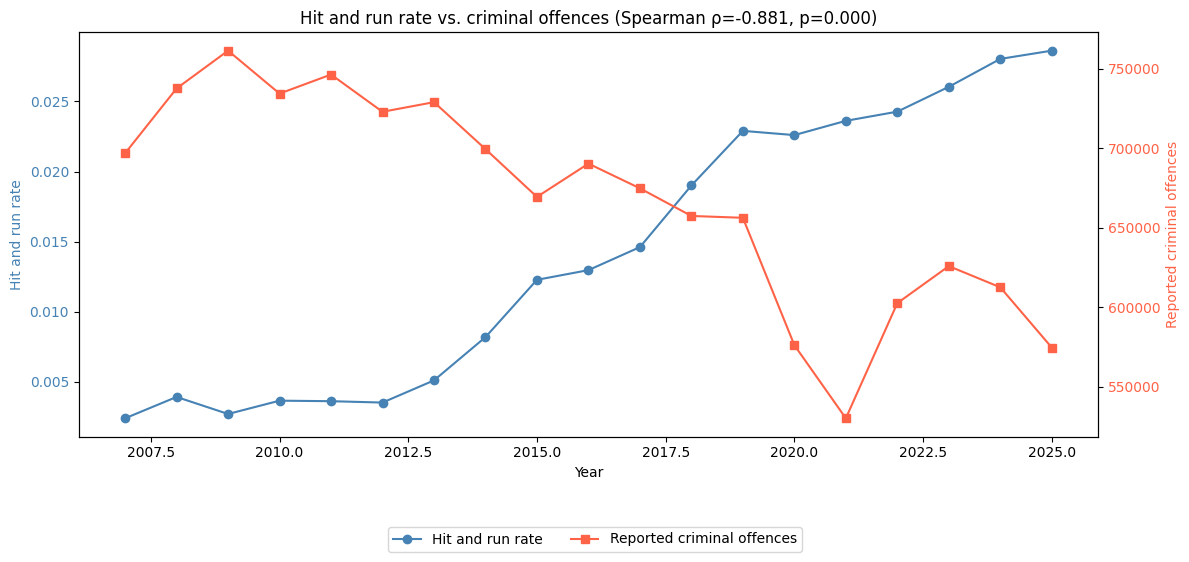

In [51]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# --- Hit and run rate per year (national) ---

yearly = df_acc.groupby("year").agg(
    total_accidents=("assigned_topic", "count"),
    hit_and_run=("assigned_topic", lambda x: (x == 11).sum())
).reset_index()
yearly["hit_and_run_rate"] = yearly["hit_and_run"] / yearly["total_accidents"]

# --- National crime total per year ---
crime_national = (
    df_crime_yearly
    .groupby("year")["reported_criminal_offences"]
    .sum()
    .reset_index()
)

# --- Merge on year ---
df_trend = yearly.merge(crime_national, on="year")

# --- Spearman correlation ---
rho, p = spearmanr(df_trend["hit_and_run_rate"], df_trend["reported_criminal_offences"])
print(f"Spearman rho: {rho:.3f}, p-value: {p:.3f}")

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(df_trend["year"], df_trend["hit_and_run_rate"], color="steelblue", marker="o", label="Hit and run rate")
ax1.set_ylabel("Hit and run rate", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(df_trend["year"], df_trend["reported_criminal_offences"], color="tomato", marker="s", label="Reported criminal offences")
ax2.set_ylabel("Reported criminal offences", color="tomato")
ax2.tick_params(axis="y", labelcolor="tomato")

fig.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=2)
ax1.set_xlabel("Year")
plt.title(f"Hit and run rate vs. criminal offences (Spearman ρ={rho:.3f}, p={p:.3f})")
plt.tight_layout()
plt.show()

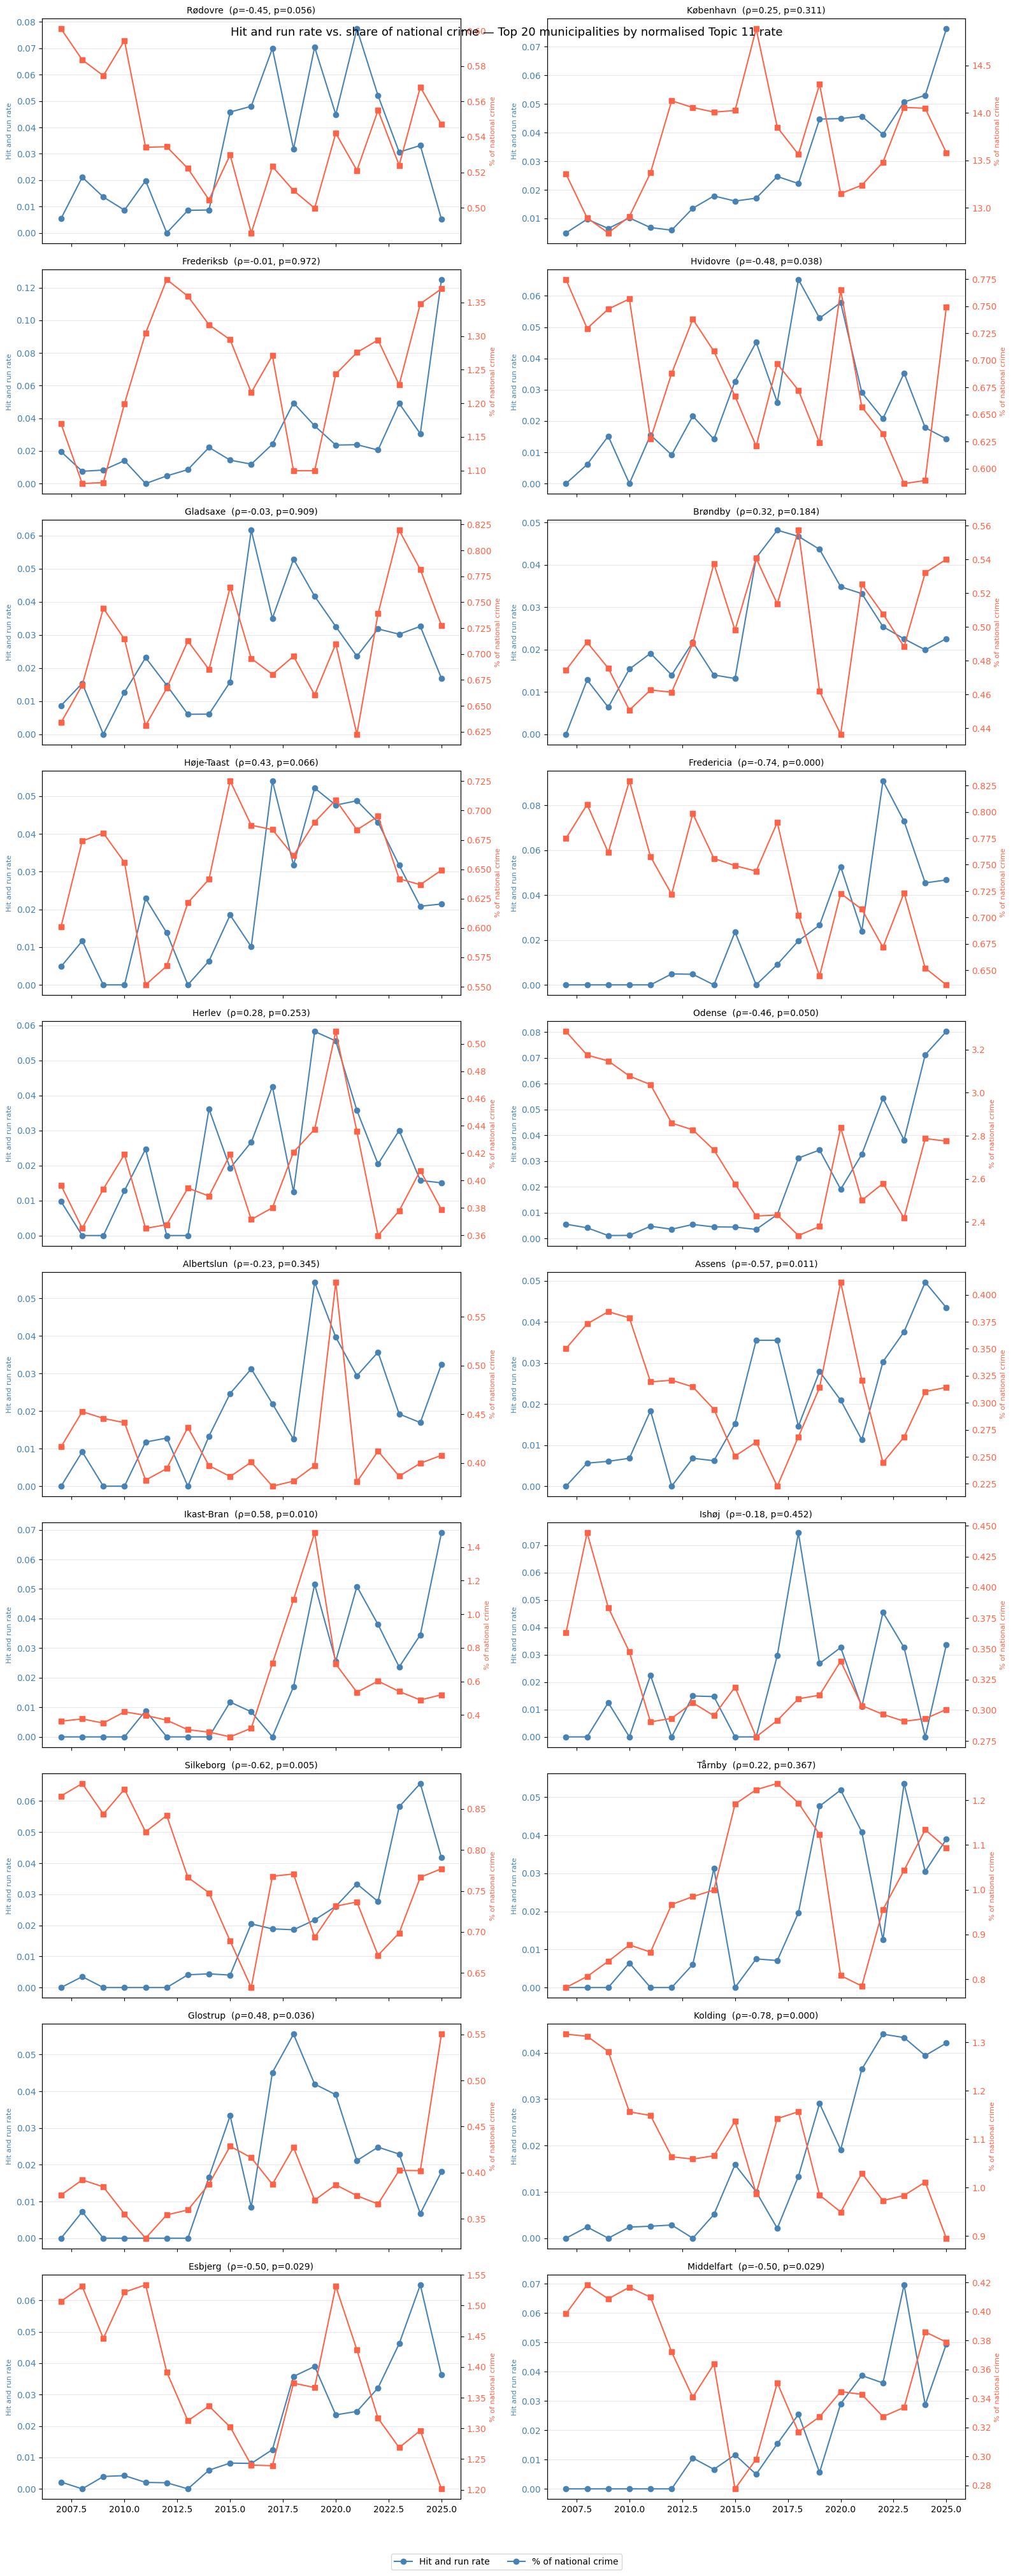

In [73]:
# Build code mapping directly from accident data
code_map = (
    df_acc_sub[["UHELDKOMMUNE", "KODE_UHELDKOMMUNE"]]
    .drop_duplicates(subset="UHELDKOMMUNE")
    .set_index("UHELDKOMMUNE")["KODE_UHELDKOMMUNE"]
    .astype(str).str.zfill(3)
)
kom_cmp["region_code"] = kom_cmp.index.map(code_map)

# Fix dtypes before merge
df_crime_yearly["region_code"] = df_crime_yearly["region_code"].astype(str).str.zfill(3)
mun_yearly["kommune_code"] = mun_yearly["KODE_UHELDKOMMUNE"].astype(str).str.zfill(3)

df_trend = mun_yearly.merge(
    df_crime_yearly[["region_code", "year", "reported_criminal_offences"]],
    left_on=["kommune_code", "year"],
    right_on=["region_code", "year"],
    how="inner"
).drop(columns=["region_code", "kommune_code"])

# National crime total per year for normalisation
national_crime = (
    df_crime_yearly.groupby("year")["reported_criminal_offences"]
    .sum()
    .reset_index()
    .rename(columns={"reported_criminal_offences": "national_crime"})
)
df_trend = df_trend.merge(national_crime, on="year", how="left")
df_trend["crime_share"] = df_trend["reported_criminal_offences"] / df_trend["national_crime"] * 100

# Top 20 by pct_of_local — exact same filter as bar chart
rate_top20 = (kom_cmp[kom_cmp["corpus_count"] >= 50]
              .sort_values("pct_of_local", ascending=False)
              .head(20))

top_kommuner_names = rate_top20.index
top_codes = kom_cmp.loc[top_kommuner_names, "region_code"].dropna().astype(str).str.zfill(3).tolist()
top_n = len(top_codes)

# Use consistent string key for filtering
df_trend["kommune_code"] = df_trend["KODE_UHELDKOMMUNE"].astype(str).str.zfill(3)
df_plot = df_trend[df_trend["kommune_code"].isin(top_codes)].sort_values("year")

fig, axes = plt.subplots(top_n // 2, 2, figsize=(16, top_n * 2), sharex=True)
axes = axes.flatten()

for ax, name in zip(axes, top_kommuner_names):
    code = str(kom_cmp.loc[name, "region_code"]).zfill(3)
    if code == "nan":
        ax.set_visible(False)
        continue
    grp = df_plot[df_plot["kommune_code"] == code]
    if grp.empty:
        ax.set_visible(False)
        continue
    rho, p = spearmanr(grp["hit_and_run_rate"], grp["crime_share"])

    ax2 = ax.twinx()
    ax.plot(grp["year"], grp["hit_and_run_rate"], color="steelblue", marker="o", linewidth=1.5, label="Hit and run rate")
    ax2.plot(grp["year"], grp["crime_share"], color="tomato", marker="s", linewidth=1.5, label="% of national crime")

    ax.set_title(f"{name}  (ρ={rho:.2f}, p={p:.3f})", fontsize=10)
    ax.set_ylabel("Hit and run rate", color="steelblue", fontsize=8)
    ax2.set_ylabel("% of national crime", color="tomato", fontsize=8)
    ax.tick_params(axis="y", labelcolor="steelblue")
    ax2.tick_params(axis="y", labelcolor="tomato")
    ax.grid(axis="y", alpha=0.3)

fig.legend(["Hit and run rate", "% of national crime"], loc="upper center",
           bbox_to_anchor=(0.5, -0.01), ncol=2)
plt.suptitle("Hit and run rate vs. share of national crime — Top 20 municipalities by normalised Topic 11 rate", fontsize=13)
plt.tight_layout()
plt.savefig("results/topic11/crime_vs_hitandrun_top_kommuner.png", dpi=150)
plt.show()

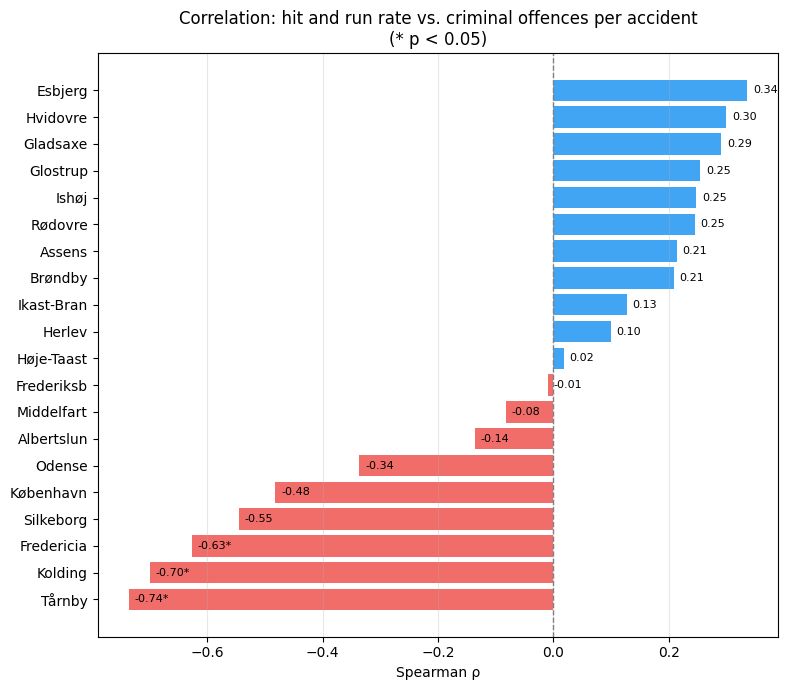

In [80]:
df_trend_plot = df_trend[df_trend["year"] >= 2015].copy()
df_trend_plot["kommune_code"] = df_trend_plot["KODE_UHELDKOMMUNE"].astype(str).str.zfill(3)
df_trend_plot["crime_per_accident"] = df_trend_plot["reported_criminal_offences"] / df_trend_plot["total_accidents"]

# Pivot
hr_pivot = df_trend_plot.pivot_table(index="KODE_UHELDKOMMUNE", columns="year", values="hit_and_run_rate")
crime_pivot = df_trend_plot.pivot_table(index="KODE_UHELDKOMMUNE", columns="year", values="crime_per_accident")

hr_pivot = hr_pivot[hr_pivot.index.astype(str).str.zfill(3).isin(top_codes)]
crime_pivot = crime_pivot[crime_pivot.index.astype(str).str.zfill(3).isin(top_codes)]

code_to_name = {str(kom_cmp.loc[n, "region_code"]).zfill(3): n for n in top_kommuner_names}
hr_pivot.index = hr_pivot.index.astype(str).str.zfill(3).map(code_to_name)
crime_pivot.index = crime_pivot.index.astype(str).str.zfill(3).map(code_to_name)

hr_pivot = hr_pivot.astype(float)
crime_pivot = crime_pivot.astype(float)

# Spearman per municipality
corr_per_kom = {}
for name in top_kommuner_names:
    code = str(kom_cmp.loc[name, "region_code"]).zfill(3)
    grp = df_trend_plot[df_trend_plot["kommune_code"] == code].sort_values("year")
    if len(grp) >= 5:
        rho, p = spearmanr(grp["hit_and_run_rate"], grp["crime_per_accident"])
        corr_per_kom[name] = {"rho": rho, "p": p}

corr_df = pd.DataFrame(corr_per_kom).T.sort_values("rho", ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))

colors = ["#2196F3" if r > 0 else "#EF5350" for r in corr_df["rho"]]
ax.barh(corr_df.index[::-1], corr_df["rho"][::-1], color=colors[::-1], alpha=0.85)
ax.axvline(0, color="grey", linestyle="--", linewidth=1)
for i, (name, row) in enumerate(corr_df.iloc[::-1].iterrows()):
    marker = "*" if row["p"] < 0.05 else ""
    ax.text(row["rho"] + 0.01, i, f'{row["rho"]:.2f}{marker}', va="center", fontsize=8)
ax.set_xlabel("Spearman ρ")
ax.set_title("Correlation: hit and run rate vs. criminal offences per accident\n(* p < 0.05)")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("results/topic11/crime_hitandrun_correlation.png", dpi=150)
plt.show()

Alcohol — chi2=306.5, p=0.0000
Light   — chi2=2041.7,   p=0.0000


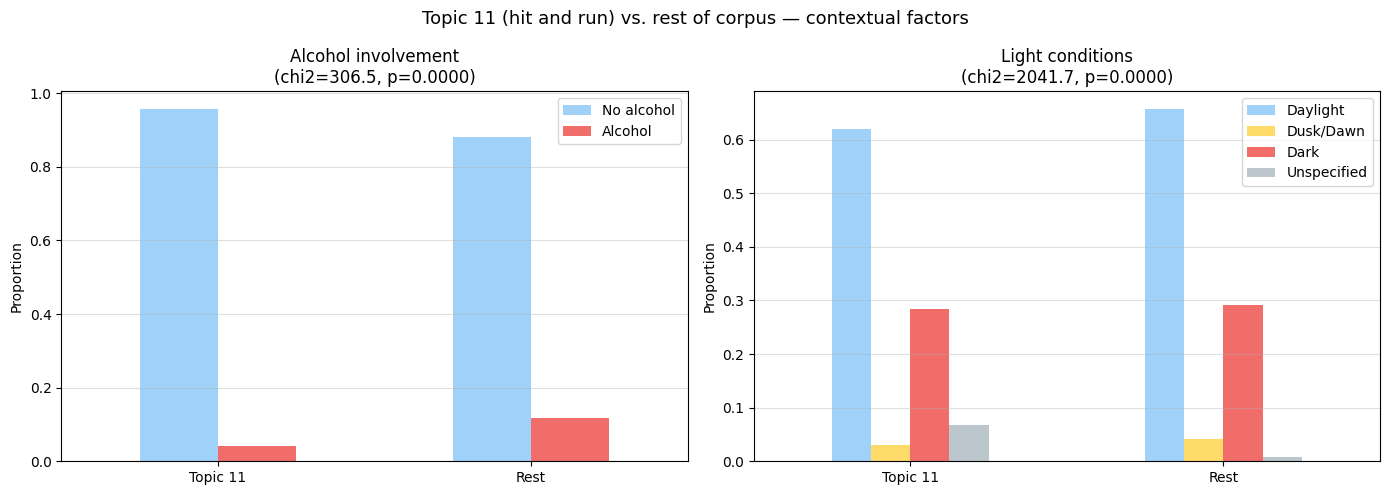

In [102]:
t11     = df_acc[df_acc["assigned_topic"] == 11].copy()
not_t11 = df_acc[df_acc["assigned_topic"] != 11].copy()

# --- 1. Alcohol involvement ---
alcohol = pd.DataFrame({
    "Topic 11":    t11["sprit_flag"].value_counts(normalize=True),
    "Rest":        not_t11["sprit_flag"].value_counts(normalize=True)
}).T
alcohol.columns = ["No alcohol", "Alcohol"]

# --- 2. Light conditions ---
lys_order = ["Dagsl", "Tusmk", "Mørke", "Uopl"]
lys = pd.DataFrame({
    "Topic 11":    t11["LYS"].value_counts(normalize=True),
    "Rest":        not_t11["LYS"].value_counts(normalize=True)
}).T.reindex(columns=lys_order)
lys.columns = ["Daylight", "Dusk/Dawn", "Dark", "Unspecified"]

# --- 3. Chi-square significance tests ---
from scipy.stats import chi2_contingency

def chi2_test(col):
    ct = pd.crosstab(df_acc["assigned_topic"] == 11, df_acc[col])
    chi2, p, dof, _ = chi2_contingency(ct)
    return chi2, p

chi2_sprit, p_sprit = chi2_test("sprit_flag")
chi2_lys,   p_lys   = chi2_test("LYS")

print(f"Alcohol — chi2={chi2_sprit:.1f}, p={p_sprit:.4f}")
print(f"Light   — chi2={chi2_lys:.1f},   p={p_lys:.4f}")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Topic 11 (hit and run) vs. rest of corpus — contextual factors", fontsize=13)

alcohol.plot(kind="bar", ax=axes[0], color=["#90CAF9", "#EF5350"], alpha=0.85, width=0.5)
axes[0].set_title(f"Alcohol involvement\n(chi2={chi2_sprit:.1f}, p={p_sprit:.4f})")
axes[0].set_ylabel("Proportion")
axes[0].set_xticklabels(["Topic 11", "Rest"], rotation=0)
axes[0].legend(["No alcohol", "Alcohol"])
axes[0].grid(axis="y", alpha=0.4)

lys.plot(kind="bar", ax=axes[1], color=["#90CAF9", "#FFD54F", "#EF5350", "#B0BEC5"], alpha=0.85, width=0.5)
axes[1].set_title(f"Light conditions\n(chi2={chi2_lys:.1f}, p={p_lys:.4f})")
axes[1].set_ylabel("Proportion")
axes[1].set_xticklabels(["Topic 11", "Rest"], rotation=0)
axes[1].legend(["Daylight", "Dusk/Dawn", "Dark", "Unspecified"])
axes[1].grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("results/topic11/alcohol_light_comparison.png", dpi=150)
plt.show()